In [1]:
#!pip install matplotlib

In [2]:
import requests
import numpy as np
import json
import pandas as pd

import copy


import matplotlib.pyplot as plt

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import datetime


# Access simulation model data

In [3]:
model_data_NonG36NoDf = pd.read_csv('ExampleSimulationData/FlexlabX1aNonG36NoDemandFlexibility.csv',encoding = 'latin1', parse_dates = True)
model_data_NonG36LoadShed = pd.read_csv('ExampleSimulationData/FlexlabX1aNonG36LoadShed.csv', encoding = 'latin1',parse_dates = True)
model_data_NonG36LoadShift = pd.read_csv('ExampleSimulationData/FlexlabX1aNonG36LoadShift.csv', encoding = 'latin1',parse_dates = True)
model_data_G36NoDf = pd.read_csv('ExampleSimulationData/FlexlabX1aG36NoDemandFlexibility.csv',encoding = 'latin1', parse_dates = True)
model_data_G36LoadShed = pd.read_csv('ExampleSimulationData/FlexlabX1aG36LoadShed.csv',encoding = 'latin1', parse_dates = True)
model_data_G36LoadShift = pd.read_csv('ExampleSimulationData/FlexlabX1aG36LoadShift.csv',encoding = 'latin1', parse_dates = True)



In [4]:
def process_model_data_time(model_data):

    model_data['datetime'] = pd.to_datetime(model_data["time"], unit='s',origin='2021-01-01') 

    model_data['datetime'] = pd.to_datetime(model_data['datetime'])

    model_data_new=model_data.set_index('datetime')
    model_data_new['date']=model_data_new.index.date
    model_data_new['time']=model_data_new.index.time
    return model_data_new

In [5]:
model_data_NonG36NoDf=process_model_data_time(model_data_NonG36NoDf)
model_data_NonG36LoadShed=process_model_data_time(model_data_NonG36LoadShed)
model_data_NonG36LoadShift=process_model_data_time(model_data_NonG36LoadShift)
model_data_G36NoDf=process_model_data_time(model_data_G36NoDf)
model_data_G36LoadShed=process_model_data_time(model_data_G36LoadShed)
model_data_G36LoadShift=process_model_data_time(model_data_G36LoadShift)

# Access FLEXLAB test data

In [6]:
test_data_cell1A_unprocessed = pd.read_csv('FlexlabData/HIL2021_x1a.csv',encoding = 'latin1', parse_dates = True)
test_data_cell1B_unprocessed = pd.read_csv('FlexlabData/HIL2021_x1b.csv',encoding = 'latin1', parse_dates = True)

In [7]:
def process_test_data_time(test_data):
    
    test_data['time']=pd.to_datetime(test_data['time'])
    test_data=test_data.set_index('time')
    test_data_new=test_data.resample('1min').mean().interpolate()
    test_data_new['date']=test_data_new.index.date
    test_data_new['time']=test_data_new.index.time
    return test_data_new

In [8]:
test_data_cell1A_unprocessed=process_test_data_time(test_data_cell1A_unprocessed)
test_data_cell1B_unprocessed=process_test_data_time(test_data_cell1B_unprocessed)

# Match the name of the FLEXLAB data points to the model data points

In [9]:
test_data_cell1A_points=['1A-VAV1-DischargeAirflow',
                   '1A-VAV2-DischargeAirflow',
                   '1A-VAV3-DischargeAirflow',
                   '1A-VAV1-DischargeAirTemp',
                   '1A-VAV2-DischargeAirTemp',
                   '1A-VAV3-DischargeAirTemp',
                   '1A-VAV1-Zn_Temp',
                   '1A-VAV2-Zn_Temp',
                   '1A-VAV3-Zn_Temp',
                   '1A-SAT-1',
                   '1A-ASAM-1',
                   '1A-El-AHU',
                   '1A-OADA-1-POSN',
                   '1A-Th-Chilled Water',
                      '1A-SAT-SP',
                   '1A-FILDPS-1',
                   '1A-SAP-SP',
                   '1A-TR-SAP-R',
                   'VAV: Leakage Airflow Rate',
                   '1A-TR-SAT-R',
                   '1A-RADA-1-POSN',
                   '1A-EADA-1-POSN',
                   '1A-OAT-1',
                   '1A-VAV1-VAVActuatorPosition',
                   '1A-VAV1-HeatOutput',
                  '1A-VAV2-VAVActuatorPosition',
                  '1A-VAV2-HeatOutput',
                  '1A-VAV3-VAVActuatorPosition',
                  '1A-VAV3-HeatOutput',
                   '1A-CHWSTS-2',
                   '1A-CHWFM-2',
                   '1A-MAT-1',
                   '1A-VAV1-RmClgLp',
                   '1A-VAV2-RmClgLp',
                   '1A-VAV3-RmClgLp',
                   '1A-RAT-1',
                   '1A-ARAM-1',

                   ]
test_data_cell1A_points

['1A-VAV1-DischargeAirflow',
 '1A-VAV2-DischargeAirflow',
 '1A-VAV3-DischargeAirflow',
 '1A-VAV1-DischargeAirTemp',
 '1A-VAV2-DischargeAirTemp',
 '1A-VAV3-DischargeAirTemp',
 '1A-VAV1-Zn_Temp',
 '1A-VAV2-Zn_Temp',
 '1A-VAV3-Zn_Temp',
 '1A-SAT-1',
 '1A-ASAM-1',
 '1A-El-AHU',
 '1A-OADA-1-POSN',
 '1A-Th-Chilled Water',
 '1A-SAT-SP',
 '1A-FILDPS-1',
 '1A-SAP-SP',
 '1A-TR-SAP-R',
 'VAV: Leakage Airflow Rate',
 '1A-TR-SAT-R',
 '1A-RADA-1-POSN',
 '1A-EADA-1-POSN',
 '1A-OAT-1',
 '1A-VAV1-VAVActuatorPosition',
 '1A-VAV1-HeatOutput',
 '1A-VAV2-VAVActuatorPosition',
 '1A-VAV2-HeatOutput',
 '1A-VAV3-VAVActuatorPosition',
 '1A-VAV3-HeatOutput',
 '1A-CHWSTS-2',
 '1A-CHWFM-2',
 '1A-MAT-1',
 '1A-VAV1-RmClgLp',
 '1A-VAV2-RmClgLp',
 '1A-VAV3-RmClgLp',
 '1A-RAT-1',
 '1A-ARAM-1']

In [10]:
test_data_cell1B_points=['1B-VAV1-DischargeAirflow',
                   '1B-VAV2-DischargeAirflow',
                   '1B-VAV3-DischargeAirflow',
                   '1B-VAV1-DischargeAirTemp',
                   '1B-VAV2-DischargeAirTemp',
                   '1B-VAV3-DischargeAirTemp',
                   '1B-VAV1-Zn_Temp',
                   '1B-VAV2-Zn_Temp',
                   '1B-VAV3-Zn_Temp',
                   '1B-SAT-1',
                   '1B-ASAM-1',
                   '1B-El-AHU',
                   '1B-OADA-1-POSN',
                   '1B-Th-Chilled Water',
                      '1B-SAT-SP',
                   '1B-FILDPS-1',
                   '1B-SAP-SP',
                   '1B-TR-SAP-R',
                   'VAV: Leakage Airflow Rate',
                   '1B-TR-SAT-R',
                   '1B-RADA-1-POSN',
                   '1B-EADA-1-POSN',
                   '1B-OAT-1',
                   '1B-VAV1-VAVActuatorPosition',
                   '1B-VAV1-HeatOutput',
                  '1B-VAV2-VAVActuatorPosition',
                  '1B-VAV2-HeatOutput',
                  '1B-VAV3-VAVActuatorPosition',
                  '1B-VAV3-HeatOutput',
                   '1B-CHWSTS-2',
                   '1B-CHWFM-2',
                   '1B-MAT-1',
                   '1B-VAV1-RmClgLp',
                   '1B-VAV2-RmClgLp',
                   '1B-VAV3-RmClgLp',
                   '1B-RAT-1',
                   '1B-ARAM-1',

                   ]
test_data_cell1B_points

['1B-VAV1-DischargeAirflow',
 '1B-VAV2-DischargeAirflow',
 '1B-VAV3-DischargeAirflow',
 '1B-VAV1-DischargeAirTemp',
 '1B-VAV2-DischargeAirTemp',
 '1B-VAV3-DischargeAirTemp',
 '1B-VAV1-Zn_Temp',
 '1B-VAV2-Zn_Temp',
 '1B-VAV3-Zn_Temp',
 '1B-SAT-1',
 '1B-ASAM-1',
 '1B-El-AHU',
 '1B-OADA-1-POSN',
 '1B-Th-Chilled Water',
 '1B-SAT-SP',
 '1B-FILDPS-1',
 '1B-SAP-SP',
 '1B-TR-SAP-R',
 'VAV: Leakage Airflow Rate',
 '1B-TR-SAT-R',
 '1B-RADA-1-POSN',
 '1B-EADA-1-POSN',
 '1B-OAT-1',
 '1B-VAV1-VAVActuatorPosition',
 '1B-VAV1-HeatOutput',
 '1B-VAV2-VAVActuatorPosition',
 '1B-VAV2-HeatOutput',
 '1B-VAV3-VAVActuatorPosition',
 '1B-VAV3-HeatOutput',
 '1B-CHWSTS-2',
 '1B-CHWFM-2',
 '1B-MAT-1',
 '1B-VAV1-RmClgLp',
 '1B-VAV2-RmClgLp',
 '1B-VAV3-RmClgLp',
 '1B-RAT-1',
 '1B-ARAM-1']

In [11]:
list_of_variables_of_interest=['VAV: North Zone Airflow Rate',
 'VAV: Core Zone Airflow Rate',
 'VAV: South Zone Airflow Rate',
 'VAV: North Zone Discharge Air Temperature',
 'VAV: Core Zone Discharge Air Temperature',
 'VAV: South Zone Discharge Air Temperature',
 'VAV: North Zone Room Air Temperature',
 'VAV: Core Zone Room Air Temperature',
 'VAV: South Zone Room Air Temperature',
 'AHU: Supply Air Temperature',

 'AHU: Supply Fan Airflow Rate',
 'AHU: Supply Fan Power',
 'AHU: Outdoor Air Damper Position',
 'AHU: Cooling Coil Load',
   'AHU: Supply Air Temperature Setpoint',
  'AHU: Supply Duct Static Pressure',
  'AHU: Supply Duct Static Pressure Setpoint',
  'AHU: Static Pressure Reset Trim And Respond Signal',
  'VAV: Leakage Airflow Rate',
  'AHU: Supply Air Temperature Reset Trim And Respond Signal',
  'AHU: Return Air Damper Position',
  'AHU: Exhaust Air Damper Position',
  'Outdoor Air Temperature',
   'VAV: North Zone Discharge Air Damper Position',
  'VAV: North Zone Reheat Valve Signal',
  'VAV: Core Zone Discharge Air Damper Position',
  'VAV: Core Zone Reheat Valve Signal',
  'VAV: South Zone Discharge Air Damper Position',
  'VAV: South Zone Reheat Valve Signal',
   'AHU: Cooling Coil Supply Water Temperature',
   'AHU: Cooling Coil Supply Water Flow Rate',
  'AHU: Mixed Air Temperature',
                 'VAV: North Zone Cooling Loop Signal',
                   'VAV: Core Zone Cooling Loop Signal',
                   'VAV: South Zone Cooling Loop Signal',
                'AHU: Return Air Temperature',
              'AHU: Return Airflow Rate',]

list_of_variables_of_interest

['VAV: North Zone Airflow Rate',
 'VAV: Core Zone Airflow Rate',
 'VAV: South Zone Airflow Rate',
 'VAV: North Zone Discharge Air Temperature',
 'VAV: Core Zone Discharge Air Temperature',
 'VAV: South Zone Discharge Air Temperature',
 'VAV: North Zone Room Air Temperature',
 'VAV: Core Zone Room Air Temperature',
 'VAV: South Zone Room Air Temperature',
 'AHU: Supply Air Temperature',
 'AHU: Supply Fan Airflow Rate',
 'AHU: Supply Fan Power',
 'AHU: Outdoor Air Damper Position',
 'AHU: Cooling Coil Load',
 'AHU: Supply Air Temperature Setpoint',
 'AHU: Supply Duct Static Pressure',
 'AHU: Supply Duct Static Pressure Setpoint',
 'AHU: Static Pressure Reset Trim And Respond Signal',
 'VAV: Leakage Airflow Rate',
 'AHU: Supply Air Temperature Reset Trim And Respond Signal',
 'AHU: Return Air Damper Position',
 'AHU: Exhaust Air Damper Position',
 'Outdoor Air Temperature',
 'VAV: North Zone Discharge Air Damper Position',
 'VAV: North Zone Reheat Valve Signal',
 'VAV: Core Zone Discharge

In [12]:
def rename_test_data(original_df, original_variable_list, new_variable_list):
    original_df=copy.deepcopy(original_df)
    rename_dict = dict(zip(original_variable_list, new_variable_list))
    new_df=original_df.rename(columns=rename_dict)
    return new_df

In [13]:
test_data_cell1A=rename_test_data(test_data_cell1A_unprocessed, test_data_cell1A_points, list_of_variables_of_interest)
#test_data_cell1A

In [14]:
test_data_cell1B=rename_test_data(test_data_cell1B_unprocessed, test_data_cell1B_points, list_of_variables_of_interest)
#test_data_cell1B

# Add additional data points

In [15]:
def add_total_cooling_load(df):
    COP=2.9
    df['chiller_load']=df['AHU: Cooling Coil Load']/COP
    df['cooling_electric_power']=df['chiller_load']+df['AHU: Supply Fan Power']

In [16]:
add_total_cooling_load(model_data_NonG36NoDf)
add_total_cooling_load(model_data_NonG36LoadShed)
add_total_cooling_load(model_data_NonG36LoadShift)
add_total_cooling_load(model_data_G36NoDf)
add_total_cooling_load(model_data_G36LoadShed)
add_total_cooling_load(model_data_G36LoadShift)
add_total_cooling_load(test_data_cell1A)
add_total_cooling_load(test_data_cell1B)

In [17]:
def calc_zat_temp_diff(df_zat):

    df_zat_diff=df_zat.apply(lambda x: x - 24 if x>18 else 18-x)

    df_zat_diff = df_zat_diff.apply(lambda x:0 if x <= 0 else x)

    return (df_zat_diff)

In [18]:
model_data_NonG36NoDf['temp_diff']=calc_zat_temp_diff(model_data_NonG36NoDf['VAV: South Zone Room Air Temperature'])
model_data_NonG36LoadShed['temp_diff']=calc_zat_temp_diff(model_data_NonG36LoadShed['VAV: South Zone Room Air Temperature'])
model_data_NonG36LoadShift['temp_diff']=calc_zat_temp_diff(model_data_NonG36LoadShift['VAV: South Zone Room Air Temperature'])
model_data_G36NoDf['temp_diff']=calc_zat_temp_diff(model_data_G36NoDf['VAV: South Zone Room Air Temperature'])
model_data_G36LoadShed['temp_diff']=calc_zat_temp_diff(model_data_G36LoadShed['VAV: South Zone Room Air Temperature'])
model_data_G36LoadShift['temp_diff']=calc_zat_temp_diff(model_data_G36LoadShift['VAV: South Zone Room Air Temperature'])
test_data_cell1A['temp_diff']=calc_zat_temp_diff(test_data_cell1A['VAV: South Zone Room Air Temperature'])
test_data_cell1B['temp_diff']=calc_zat_temp_diff(test_data_cell1B['VAV: South Zone Room Air Temperature'])

# plotting

## plotting functions

In [19]:
def convert_hours_since_midnight(time_object):
    seconds_since_midnight = time_object.hour * 3600 + time_object.minute * 60 + time_object.second
    hours_since_midnight=seconds_since_midnight/3600
    return hours_since_midnight

In [20]:
def extract_daily_data(series,date_to_select):
    date_to_select=pd.to_datetime(date_to_select).date()
    df=copy.deepcopy(series.to_frame())
    df['date']=df.index.date
    df['time']=df.index.time
    df=df.loc[df['date'].isin([date_to_select])]
    df['time']=df['time'].apply(lambda x: convert_hours_since_midnight(x))
    df.set_index('time',inplace=True)
    df=df.drop(['date'], axis=1)
    result_series=df.squeeze()
    return result_series

In [21]:
def calculate_daily_average(series):
    df=copy.deepcopy(series.to_frame())
    df['time']=df.index.time
    df.index.names = ['unnamed']
    result_df=df.groupby(['time']).mean()
    result_df['time']=result_df.index
    result_df['time']=result_df['time'].apply(lambda x: convert_hours_since_midnight(x))
    result_df.set_index('time',inplace=True)
    result_series=result_df.squeeze()
    return result_series

In [22]:
def filter_dates(series,dates_to_select):
    dates_to_select=[pd.to_datetime(date_to_select).date() for date_to_select in dates_to_select]
    df=copy.deepcopy(series.to_frame())
    df['date']=df.index.date
    df=df.loc[df['date'].isin(dates_to_select)]
    df=df.drop(['date'], axis=1)
    result_series=df.squeeze()
    return result_series

In [23]:
def filter_dates_hourly_index(series,dates_to_select):
    series=filter_dates(series,dates_to_select)
    series=smooth_function(series,15)
    result_series=calculate_daily_average(series)
    return result_series

In [24]:
def filter_dates_dataframe(df,dates_to_select):
    dates_to_select=[pd.to_datetime(date_to_select).date() for date_to_select in dates_to_select]
    df=copy.deepcopy(df)
    df['date']=df.index.date
    df=df.loc[df['date'].isin(dates_to_select)]
    result_df=df.drop(['date'], axis=1)
    return result_df

In [25]:
def return_unique_dates(series):
    df=copy.deepcopy(series.to_frame())
    df['date']=df.index.date
    unique_dates_list=list(df['date'].unique())
    return unique_dates_list

In [26]:
def smooth_function(series,minutes_resample):
    unique_days=return_unique_dates(series)
    series=series.resample(str(minutes_resample)+'min').mean()
    series=series.resample('1min').mean().interpolate()
    new_series=filter_dates(series,unique_days)
    return new_series

In [27]:
def list_subtract(list1, list2):
    result_list=[(list1[i]-list2[i]) for i in range(len(list1))]
    return result_list

In [28]:
def special_list_subtract(list1, list2):
    result_list=[(list1[i]-list2[i])*1000/56.9 for i in range(len(list1))]
    return result_list

In [29]:
def list_indexing(list1, list2):
    result_list=[list1[index] for index in list2]
    return result_list

In [30]:
#filter_dates_dataframe(model_data_NonG36NoDf[['temp_diff','cooling_electric_power']],['2021-08-26','2021-08-28'])

## data processing for plotting

In [31]:
CompareControlSequence_NoDf_days=['2021-08-15','2021-08-24','2021-08-25','2021-09-02','2021-09-03']

CompareControlSequence_LoadShed_days=['2021-08-20','2021-08-21','2021-08-22','2021-08-23','2021-09-10','2021-09-12','2021-09-13']

CompareControlSequence_LoadShift_days=['2021-08-26','2021-08-28','2021-08-29','2021-08-30','2021-08-31','2021-09-04','2021-09-05','2021-09-06','2021-09-09']

In [32]:
ZoneHeatingSetpointSchedule_NoDf=extract_daily_data(test_data_cell1B['1B-VAV3-OccupiedHeatingSetpt'],CompareControlSequence_NoDf_days[0])
ZoneCoolingSetpointSchedule_NoDf=extract_daily_data(test_data_cell1B['1B-VAV3-OccupiedCoolingSetpt'],CompareControlSequence_NoDf_days[0])

ZoneHeatingSetpointSchedule_LoadShed=extract_daily_data(test_data_cell1B['1B-VAV3-OccupiedHeatingSetpt'],CompareControlSequence_LoadShed_days[0])
ZoneCoolingSetpointSchedule_LoadShed=extract_daily_data(test_data_cell1B['1B-VAV3-OccupiedCoolingSetpt'],CompareControlSequence_LoadShed_days[0])

ZoneHeatingSetpointSchedule_LoadShift=extract_daily_data(test_data_cell1B['1B-VAV3-OccupiedHeatingSetpt'],CompareControlSequence_LoadShift_days[0])
ZoneCoolingSetpointSchedule_LoadShift=extract_daily_data(test_data_cell1B['1B-VAV3-OccupiedCoolingSetpt'],CompareControlSequence_LoadShift_days[0])

In [33]:
ZoneAirTemperature_NonG36NoDf=filter_dates(model_data_NonG36NoDf['VAV: South Zone Room Air Temperature'],CompareControlSequence_NoDf_days)


ZoneAirTemperature_NonG36LoadShed=filter_dates(model_data_NonG36LoadShed['VAV: South Zone Room Air Temperature'],CompareControlSequence_LoadShed_days)


ZoneAirTemperature_NonG36LoadShift=filter_dates(model_data_NonG36LoadShift['VAV: South Zone Room Air Temperature'],CompareControlSequence_LoadShift_days)


ZoneAirTemperature_G36NoDf=filter_dates(test_data_cell1B['VAV: South Zone Room Air Temperature'],CompareControlSequence_NoDf_days)


ZoneAirTemperature_G36LoadShed=filter_dates(test_data_cell1B['VAV: South Zone Room Air Temperature'],CompareControlSequence_LoadShed_days)


ZoneAirTemperature_G36LoadShift=filter_dates(test_data_cell1B['VAV: South Zone Room Air Temperature'],CompareControlSequence_LoadShift_days)


In [34]:
CoolingElectricPower_NonG36NoDf=filter_dates(model_data_NonG36NoDf['cooling_electric_power'],CompareControlSequence_NoDf_days)


CoolingElectricPower_NonG36LoadShed=filter_dates(model_data_NonG36LoadShed['cooling_electric_power'],CompareControlSequence_LoadShed_days)


CoolingElectricPower_NonG36LoadShift=filter_dates(model_data_NonG36LoadShift['cooling_electric_power'],CompareControlSequence_LoadShift_days)


CoolingElectricPower_G36NoDf=filter_dates(test_data_cell1B['cooling_electric_power'],CompareControlSequence_NoDf_days)


CoolingElectricPower_G36LoadShed=filter_dates(test_data_cell1B['cooling_electric_power'],CompareControlSequence_LoadShed_days)


CoolingElectricPower_G36LoadShift=filter_dates(test_data_cell1B['cooling_electric_power'],CompareControlSequence_LoadShift_days)


In [35]:
CoolingElectricPower_G36NoDf=smooth_function(CoolingElectricPower_G36NoDf,15)
CoolingElectricPower_G36LoadShed=smooth_function(CoolingElectricPower_G36LoadShed,15)
CoolingElectricPower_G36LoadShift=smooth_function(CoolingElectricPower_G36LoadShift,15)

In [36]:
MetricsCalculation_NonG36NoDf=filter_dates_dataframe(model_data_NonG36NoDf[['temp_diff','cooling_electric_power']],CompareControlSequence_NoDf_days)


MetricsCalculation_NonG36LoadShed=filter_dates_dataframe(model_data_NonG36LoadShed[['temp_diff','cooling_electric_power']],CompareControlSequence_LoadShed_days)


MetricsCalculation_NonG36LoadShift=filter_dates_dataframe(model_data_NonG36LoadShift[['temp_diff','cooling_electric_power']],CompareControlSequence_LoadShift_days)


MetricsCalculation_G36NoDf=filter_dates_dataframe(test_data_cell1B[['temp_diff','cooling_electric_power']],CompareControlSequence_NoDf_days)


MetricsCalculation_G36LoadShed=filter_dates_dataframe(test_data_cell1B[['temp_diff','cooling_electric_power']],CompareControlSequence_LoadShed_days)


MetricsCalculation_G36LoadShift=filter_dates_dataframe(test_data_cell1B[['temp_diff','cooling_electric_power']],CompareControlSequence_LoadShift_days)


In [37]:
precool_st = datetime.time(10,0,0)
precool_en = datetime.time(14,0,0)

shed_st = datetime.time(14,0,0)
shed_en = datetime.time(18,0,0)

oc_st = datetime.time(7,0,0)
oc_en = datetime.time(22,0,0)

In [38]:

def calculate_df_metrics(data_caseName_original,time_interval_minute=1):
    data_caseName=copy.deepcopy(data_caseName_original)
    data_caseName['date']=data_caseName.index.date
    data_caseName['time']=data_caseName.index.time
    dayList_caseName=data_caseName['date'].unique().tolist()
    #dayList_caseName




    shed_ts_caseName = (data_caseName['time'] >= shed_st) & (data_caseName['time'] < shed_en)
    precool_ts_caseName = (data_caseName['time'] >= precool_st) & (data_caseName['time'] < precool_en)

    occupied_caseName = (data_caseName['time'] >= oc_st) & (data_caseName['time'] < oc_en)


    avg_demand_caseName_shed=[]
    avg_demand_caseName_pc=[]
    total_energy_caseName=[]
    daily_shoot_caseName=[]

    for day in dayList_caseName:    

        mask_day = data_caseName['date'] == day



        day_energy_caseName = round(data_caseName['cooling_electric_power'][mask_day].sum()/1000/60*time_interval_minute,3)
        total_energy_caseName.append(day_energy_caseName)    


        day_avg_power_caseName_shed = round(data_caseName['cooling_electric_power'][mask_day][shed_ts_caseName].mean()/1000,3)

        avg_demand_caseName_shed.append(day_avg_power_caseName_shed)

        day_avg_power_caseName_pc = round(data_caseName['cooling_electric_power'][mask_day][precool_ts_caseName].mean()/1000,3)

        avg_demand_caseName_pc.append(day_avg_power_caseName_pc)

        daily_shoot_per_day_caseName = round(sum(data_caseName['temp_diff'][mask_day][occupied_caseName]/60*time_interval_minute),3)
        daily_shoot_caseName.append(daily_shoot_per_day_caseName)


    #print("list_of_days: ",dayList_caseName)    
    #print("total_energy: ",total_energy_caseName,np.mean(total_energy_caseName))

    #print("average demand shed: ",avg_demand_caseName_shed,np.mean(avg_demand_caseName_shed))
    #print("average demand pc: ",avg_demand_caseName_pc,np.mean(avg_demand_caseName_pc))
    #print("daily_shoot: ",daily_shoot_caseName,np.mean(daily_shoot_caseName))
    return total_energy_caseName, avg_demand_caseName_shed, avg_demand_caseName_pc, daily_shoot_caseName

In [39]:
DailyTotalEnergy_NonG36NoDf,AverageDemandShed_NonG36NoDf,AverageDemandPrecool_NonG36NoDf,_=calculate_df_metrics(MetricsCalculation_NonG36NoDf)
#DailyTotalEnergy_NonG36NoDf

DailyTotalEnergy_G36NoDf,AverageDemandShed_G36NoDf,AverageDemandPrecool_G36NoDf,_=calculate_df_metrics(MetricsCalculation_G36NoDf)
#DailyTotalEnergy_G36NoDf

In [40]:
DailyTotalEnergy_NonG36LoadShed,AverageDemandShed_NonG36LoadShed,AverageDemandPrecool_NonG36LoadShed,_=calculate_df_metrics(MetricsCalculation_NonG36LoadShed)
DailyTotalEnergy_NonG36LoadShed

DailyTotalEnergy_G36LoadShed,AverageDemandShed_G36LoadShed,AverageDemandPrecool_G36LoadShed,_=calculate_df_metrics(MetricsCalculation_G36LoadShed)
DailyTotalEnergy_G36LoadShed

[3.262, 2.629, 5.668, 3.023, 7.012, 9.649, 9.94]

In [41]:
DailyTotalEnergy_NonG36LoadShift,AverageDemandShed_NonG36LoadShift,AverageDemandPrecool_NonG36LoadShift,_=calculate_df_metrics(MetricsCalculation_NonG36LoadShift)
DailyTotalEnergy_NonG36LoadShift

DailyTotalEnergy_G36LoadShift,AverageDemandShed_G36LoadShift,AverageDemandPrecool_G36LoadShift,_=calculate_df_metrics(MetricsCalculation_G36LoadShift)
DailyTotalEnergy_G36LoadShift

[9.13, 14.482, 9.859, 8.373, 8.091, 8.372, 10.946, 13.51, 9.188]

## creating plots

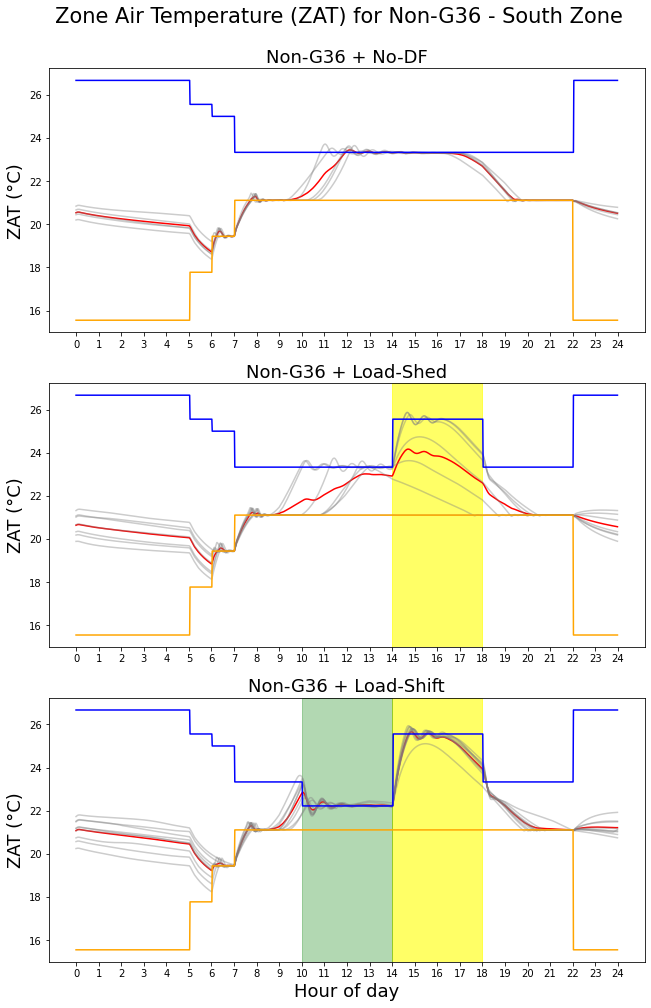

In [42]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(9,13))
fig.tight_layout(h_pad=3)
fig.suptitle('Zone Air Temperature (ZAT) for Non-G36 - South Zone', fontsize=21, x=0.5, y=1.05)
#--------------------------------------
ax[0].plot(calculate_daily_average(ZoneAirTemperature_NonG36NoDf),color="red",alpha=1)
for day in CompareControlSequence_NoDf_days:
    ax[0].plot(extract_daily_data(ZoneAirTemperature_NonG36NoDf,day),color="gray",alpha=0.4)

ax[0].plot(ZoneCoolingSetpointSchedule_NoDf,color='blue')
ax[0].plot(ZoneHeatingSetpointSchedule_NoDf,color='orange')

ax[0].set_title('Non-G36 + No-DF',fontsize=18)
ax[0].set_ylabel('ZAT (°C)',fontsize=18)
_=ax[0].set_xticks(list(range(0,25)))
#--------------------------------------
ax[1].plot(calculate_daily_average(ZoneAirTemperature_NonG36LoadShed),color="red",alpha=1)
for day in CompareControlSequence_LoadShed_days:
    ax[1].plot(extract_daily_data(ZoneAirTemperature_NonG36LoadShed,day),color="gray",alpha=0.4)

ax[1].plot(ZoneCoolingSetpointSchedule_LoadShed,color='blue')
ax[1].plot(ZoneHeatingSetpointSchedule_LoadShed,color='orange')

ax[1].set_title('Non-G36 + Load-Shed',fontsize=18)
ax[1].set_ylabel('ZAT (°C)',fontsize=18)
_=ax[1].set_xticks(list(range(0,25)))
ax[1].axvspan(14, 18, alpha=0.6,color='yellow')
#--------------------------------------
ax[2].plot(calculate_daily_average(ZoneAirTemperature_NonG36LoadShift),color="red",alpha=1)
for day in CompareControlSequence_LoadShift_days:
    ax[2].plot(extract_daily_data(ZoneAirTemperature_NonG36LoadShift,day),color="gray",alpha=0.4)

ax[2].plot(ZoneCoolingSetpointSchedule_LoadShift,color='blue')
ax[2].plot(ZoneHeatingSetpointSchedule_LoadShift,color='orange')

ax[2].set_title('Non-G36 + Load-Shift',fontsize=18)
ax[2].set_ylabel('ZAT (°C)',fontsize=18)
ax[2].set_xlabel('Hour of day',fontsize=18)
_=ax[2].set_xticks(list(range(0,25)))
ax[2].axvspan(14, 18, alpha=0.6,color='yellow')
ax[2].axvspan(10, 14, alpha=0.3,color='green')

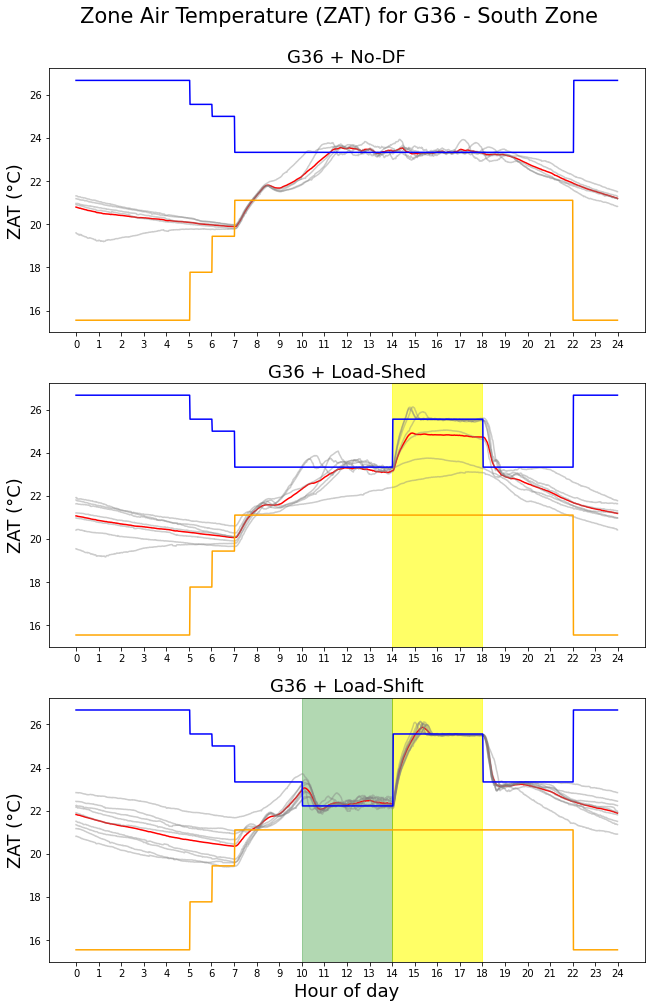

In [43]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(9,13))
fig.tight_layout(h_pad=3)
fig.suptitle('Zone Air Temperature (ZAT) for G36 - South Zone', fontsize=21, x=0.5, y=1.05)
#--------------------------------------
ax[0].plot(calculate_daily_average(ZoneAirTemperature_G36NoDf),color="red",alpha=1)
for day in CompareControlSequence_NoDf_days:
    ax[0].plot(extract_daily_data(ZoneAirTemperature_G36NoDf,day),color="gray",alpha=0.4)

ax[0].plot(ZoneCoolingSetpointSchedule_NoDf,color='blue')
ax[0].plot(ZoneHeatingSetpointSchedule_NoDf,color='orange')

ax[0].set_title('G36 + No-DF',fontsize=18)
ax[0].set_ylabel('ZAT (°C)',fontsize=18)
_=ax[0].set_xticks(list(range(0,25)))
#--------------------------------------
ax[1].plot(calculate_daily_average(ZoneAirTemperature_G36LoadShed),color="red",alpha=1)
for day in CompareControlSequence_LoadShed_days:
    ax[1].plot(extract_daily_data(ZoneAirTemperature_G36LoadShed,day),color="gray",alpha=0.4)

ax[1].plot(ZoneCoolingSetpointSchedule_LoadShed,color='blue')
ax[1].plot(ZoneHeatingSetpointSchedule_LoadShed,color='orange')

ax[1].set_title('G36 + Load-Shed',fontsize=18)
ax[1].set_ylabel('ZAT (°C)',fontsize=18)
_=ax[1].set_xticks(list(range(0,25)))
ax[1].axvspan(14, 18, alpha=0.6,color='yellow')
#--------------------------------------
ax[2].plot(calculate_daily_average(ZoneAirTemperature_G36LoadShift),color="red",alpha=1)
for day in CompareControlSequence_LoadShift_days:
    ax[2].plot(extract_daily_data(ZoneAirTemperature_G36LoadShift,day),color="gray",alpha=0.4)

ax[2].plot(ZoneCoolingSetpointSchedule_LoadShift,color='blue')
ax[2].plot(ZoneHeatingSetpointSchedule_LoadShift,color='orange')

ax[2].set_title('G36 + Load-Shift',fontsize=18)
ax[2].set_ylabel('ZAT (°C)',fontsize=18)
ax[2].set_xlabel('Hour of day',fontsize=18)
_=ax[2].set_xticks(list(range(0,25)))
ax[2].axvspan(14, 18, alpha=0.6,color='yellow')
ax[2].axvspan(10, 14, alpha=0.3,color='green')

(0.0, 2000.0)

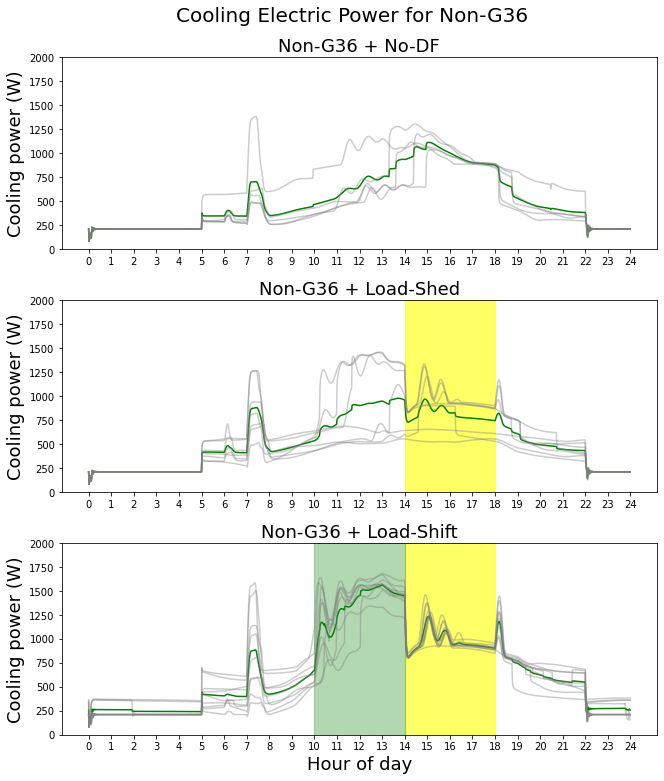

In [44]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(9,10))
fig.tight_layout(h_pad=3)
fig.suptitle('Cooling Electric Power for Non-G36', fontsize=20, x=0.5, y=1.05)
#--------------------------------------
ax[0].plot(calculate_daily_average(CoolingElectricPower_NonG36NoDf),color="green",alpha=1)
for day in CompareControlSequence_NoDf_days:
    ax[0].plot(extract_daily_data(CoolingElectricPower_NonG36NoDf,day),color="gray",alpha=0.4)

ax[0].set_title('Non-G36 + No-DF',fontsize=18)
ax[0].set_ylabel('Cooling power (W)',fontsize=18)
_=ax[0].set_xticks(list(range(0,25)))
ax[0].set_ylim(0,2000)
#--------------------------------------
ax[1].plot(calculate_daily_average(CoolingElectricPower_NonG36LoadShed),color="green",alpha=1)
for day in CompareControlSequence_LoadShed_days:
    ax[1].plot(extract_daily_data(CoolingElectricPower_NonG36LoadShed,day),color="gray",alpha=0.4)

ax[1].set_title('Non-G36 + Load-Shed',fontsize=18)
ax[1].set_ylabel('Cooling power (W)',fontsize=18)
_=ax[1].set_xticks(list(range(0,25)))
ax[1].axvspan(14, 18, alpha=0.6,color='yellow')
ax[1].set_ylim(0,2000)
#--------------------------------------
ax[2].plot(calculate_daily_average(CoolingElectricPower_NonG36LoadShift),color="green",alpha=1)
for day in CompareControlSequence_LoadShift_days:
    ax[2].plot(extract_daily_data(CoolingElectricPower_NonG36LoadShift,day),color="gray",alpha=0.4)

ax[2].set_title('Non-G36 + Load-Shift',fontsize=18)
ax[2].set_ylabel('Cooling power (W)',fontsize=18)
ax[2].set_xlabel('Hour of day',fontsize=18)
_=ax[2].set_xticks(list(range(0,25)))
ax[2].axvspan(14, 18, alpha=0.6,color='yellow')
ax[2].axvspan(10, 14, alpha=0.3,color='green')
ax[2].set_ylim(0,2000)

In [45]:
CoolingElectricPower_G36NoDf

time
2021-08-15 00:00:00    493.617041
2021-08-15 00:01:00    490.774699
2021-08-15 00:02:00    487.932356
2021-08-15 00:03:00    485.090013
2021-08-15 00:04:00    482.247671
                          ...    
2021-09-03 23:41:00     96.802022
2021-09-03 23:42:00     96.804475
2021-09-03 23:43:00     96.806928
2021-09-03 23:44:00     96.809381
2021-09-03 23:45:00     96.811835
Name: cooling_electric_power, Length: 7186, dtype: float64

(0.0, 2000.0)

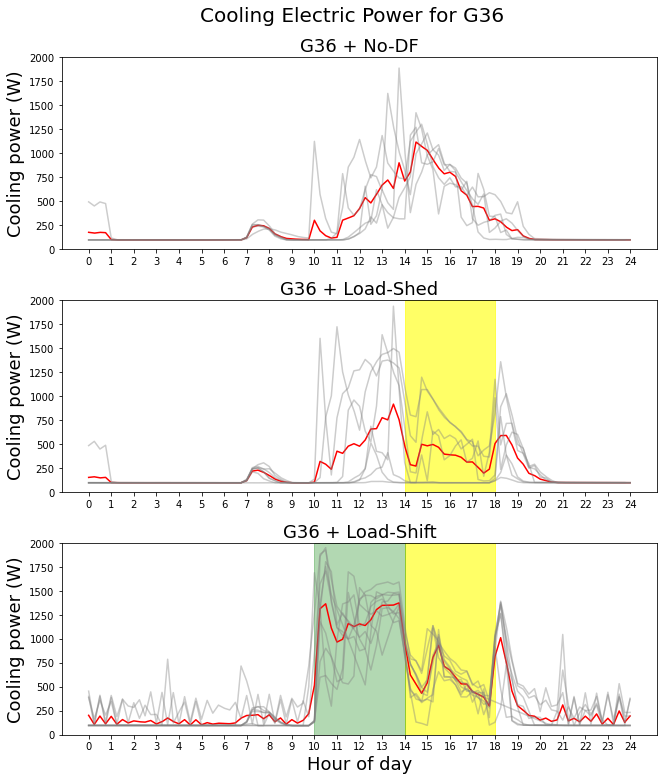

In [46]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(9,10))
fig.tight_layout(h_pad=3)
fig.suptitle('Cooling Electric Power for G36', fontsize=20, x=0.5, y=1.05)
#--------------------------------------
ax[0].plot(calculate_daily_average(CoolingElectricPower_G36NoDf),color="red",alpha=1)
for day in CompareControlSequence_NoDf_days:
    ax[0].plot(extract_daily_data(CoolingElectricPower_G36NoDf,day),color="gray",alpha=0.4)

ax[0].set_title('G36 + No-DF',fontsize=18)
ax[0].set_ylabel('Cooling power (W)',fontsize=18)
_=ax[0].set_xticks(list(range(0,25)))
ax[0].set_ylim(0,2000)
#--------------------------------------
ax[1].plot(calculate_daily_average(CoolingElectricPower_G36LoadShed),color="red",alpha=1)
for day in CompareControlSequence_LoadShed_days:
    ax[1].plot(extract_daily_data(CoolingElectricPower_G36LoadShed,day),color="gray",alpha=0.4)

ax[1].set_title('G36 + Load-Shed',fontsize=18)
ax[1].set_ylabel('Cooling power (W)',fontsize=18)
_=ax[1].set_xticks(list(range(0,25)))
ax[1].axvspan(14, 18, alpha=0.6,color='yellow')
ax[1].set_ylim(0,2000)
#--------------------------------------
ax[2].plot(calculate_daily_average(CoolingElectricPower_G36LoadShift),color="red",alpha=1)
for day in CompareControlSequence_LoadShift_days:
    ax[2].plot(extract_daily_data(CoolingElectricPower_G36LoadShift,day),color="gray",alpha=0.4)

ax[2].set_title('G36 + Load-Shift',fontsize=18)
ax[2].set_ylabel('Cooling power (W)',fontsize=18)
ax[2].set_xlabel('Hour of day',fontsize=18)
_=ax[2].set_xticks(list(range(0,25)))
ax[2].axvspan(14, 18, alpha=0.6,color='yellow')
ax[2].axvspan(10, 14, alpha=0.3,color='green')
ax[2].set_ylim(0,2000)

In [47]:
CompareControlSequence_NoDf_days

['2021-08-15', '2021-08-24', '2021-08-25', '2021-09-02', '2021-09-03']

In [48]:
aaa=[pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in CompareControlSequence_NoDf_days]
aaa

['08/15', '08/24', '08/25', '09/02', '09/03']

In [49]:
full_dates=['2021-08-15','2021-08-21','2021-08-24','2021-08-25','2021-08-30','2021-08-31','2021-09-02','2021-09-03','2021-09-04','2021-09-05','2021-09-08','2021-09-09','2021-09-10','2021-09-12']


In [50]:
[full_dates[i] for i in [4,5,10,11,12,13]]

['2021-08-30',
 '2021-08-31',
 '2021-09-08',
 '2021-09-09',
 '2021-09-10',
 '2021-09-12']

In [51]:
[full_dates[i] for i in [0,2,3,6,7]]

['2021-08-15', '2021-08-24', '2021-08-25', '2021-09-02', '2021-09-03']

In [52]:
"""
#MetricsCalculation_UseModel_G36NoDf=filter_dates_dataframe(model_data_G36NoDf[['temp_diff','cooling_electric_power']],CompareControlSequence_NoDf_days)



full_dates=['2021-08-15','2021-08-21','2021-08-24','2021-08-25','2021-08-30','2021-08-31','2021-09-02','2021-09-03','2021-09-04','2021-09-05','2021-09-08','2021-09-09','2021-09-10','2021-09-12']

MetricsCalculation_UseModel_NonG36NoDf=filter_dates_dataframe(model_data_NonG36NoDf[['temp_diff','cooling_electric_power']],[full_dates[i] for i in [0,2,3,4,5,6,7,10,11,12,13]])
MetricsCalculation_UseModel_G36NoDf=filter_dates_dataframe(model_data_G36NoDf[['temp_diff','cooling_electric_power']],[full_dates[i] for i in [1,8,9]])
MetricsCalculation_UseTest1A_NonG36NoDf=filter_dates_dataframe(test_data_cell1A[['temp_diff','cooling_electric_power']],[full_dates[i] for i in [1,8,9]])
MetricsCalculation_UseTest1A_G36NoDf=filter_dates_dataframe(test_data_cell1A[['temp_diff','cooling_electric_power']],[full_dates[i] for i in [4,5,10,11,12,13]])
MetricsCalculation_UseTest1B_G36NoDf=filter_dates_dataframe(test_data_cell1B[['temp_diff','cooling_electric_power']],[full_dates[i] for i in [0,2,3,6,7]])

DailyTotalEnergy_UseModel_NonG36NoDf,AverageDemandShed_UseModel_NonG36NoDf,AverageDemandPrecool_UseModel_NonG36NoDf,_=calculate_df_metrics(MetricsCalculation_UseModel_NonG36NoDf)
DailyTotalEnergy_UseModel_G36NoDf,AverageDemandShed_UseModel_G36NoDf,AverageDemandPrecool_UseModel_G36NoDf,_=calculate_df_metrics(MetricsCalculation_UseModel_G36NoDf)
DailyTotalEnergy_UseTest1A_NonG36NoDf,AverageDemandShed_UseTest1A_NonG36NoDf,AverageDemandPrecool_UseTest1A_NonG36NoDf,_=calculate_df_metrics(MetricsCalculation_UseTest1A_NonG36NoDf)
DailyTotalEnergy_UseTest1A_G36NoDf,AverageDemandShed_UseTest1A_G36NoDf,AverageDemandPrecool_UseTest1A_G36NoDf,_=calculate_df_metrics(MetricsCalculation_UseTest1A_G36NoDf)
DailyTotalEnergy_UseTest1B_G36NoDf,AverageDemandShed_UseTest1B_G36NoDf,AverageDemandPrecool_UseTest1B_G36NoDf,_=calculate_df_metrics(MetricsCalculation_UseTest1B_G36NoDf)

fig, (ax) = plt.subplots(nrows = 1, ncols = 1, constrained_layout=False, facecolor='w', edgecolor='k',figsize = (14,7))
fig.subplots_adjust(hspace = .2, wspace=.15)



# create labels for each date of the test
labels = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in full_dates]


x = np.arange(len(labels))
width = .2

ax.bar(np.array([0,2,3,4,5,6,7,10,11,12,13])-width*0.5, DailyTotalEnergy_UseModel_NonG36NoDf, width = width, color = 'grey')
ax.bar(np.array([4,5,10,11,12,13])+width*0.5, DailyTotalEnergy_UseTest1A_G36NoDf, width = width, color = 'indianred',hatch= 'xx')
ax.bar(np.array([0,2,3,6,7])+width*0.5, DailyTotalEnergy_UseTest1B_G36NoDf, width = width, color = 'indianred',hatch= 'xx')

ax.bar(np.array([1,8,9])-width*0.5, DailyTotalEnergy_UseTest1A_NonG36NoDf, width = width, color = 'grey',hatch= 'xx')
ax.bar(np.array([1,8,9])+width*0.5, DailyTotalEnergy_UseModel_G36NoDf, width = width, color = 'indianred')

#ax.bar(x+width*.5, en_g36, width = width, label='G36 Control', color = 'rosybrown')
#ax.bar(x+width*1.5, en_g36_dr, width = width, label='G36 Control + DR', color = 'indianred')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize = 12)
ax.set_title('Daily Energy Consumption', fontsize = 22)
ax.set_ylabel('Energy (kWh)', fontsize = 18)
grey_patch = mpatches.Patch(color='grey', label='non-G36 + no-DF')
indianred_patch = mpatches.Patch(color='indianred', label='G36 + no-DF')
simulated_patch = mpatches.Patch(label='simulated data',edgecolor='black',facecolor='white')
experimental_patch = mpatches.Patch(label='experimental data',edgecolor='black',facecolor='white',hatch= 'xx')
ax.legend(handles=[grey_patch, indianred_patch,simulated_patch,experimental_patch],fontsize = 14)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)
"""

'\n#MetricsCalculation_UseModel_G36NoDf=filter_dates_dataframe(model_data_G36NoDf[[\'temp_diff\',\'cooling_electric_power\']],CompareControlSequence_NoDf_days)\n\n\n\nfull_dates=[\'2021-08-15\',\'2021-08-21\',\'2021-08-24\',\'2021-08-25\',\'2021-08-30\',\'2021-08-31\',\'2021-09-02\',\'2021-09-03\',\'2021-09-04\',\'2021-09-05\',\'2021-09-08\',\'2021-09-09\',\'2021-09-10\',\'2021-09-12\']\n\nMetricsCalculation_UseModel_NonG36NoDf=filter_dates_dataframe(model_data_NonG36NoDf[[\'temp_diff\',\'cooling_electric_power\']],[full_dates[i] for i in [0,2,3,4,5,6,7,10,11,12,13]])\nMetricsCalculation_UseModel_G36NoDf=filter_dates_dataframe(model_data_G36NoDf[[\'temp_diff\',\'cooling_electric_power\']],[full_dates[i] for i in [1,8,9]])\nMetricsCalculation_UseTest1A_NonG36NoDf=filter_dates_dataframe(test_data_cell1A[[\'temp_diff\',\'cooling_electric_power\']],[full_dates[i] for i in [1,8,9]])\nMetricsCalculation_UseTest1A_G36NoDf=filter_dates_dataframe(test_data_cell1A[[\'temp_diff\',\'cooling_electr

In [53]:
"""
#MetricsCalculation_UseModel_G36NoDf=filter_dates_dataframe(model_data_G36NoDf[['temp_diff','cooling_electric_power']],CompareControlSequence_NoDf_days)



full_dates=['2021-08-15','2021-08-21','2021-08-24','2021-08-25','2021-08-30','2021-08-31','2021-09-02','2021-09-03','2021-09-04','2021-09-05','2021-09-08','2021-09-09','2021-09-10','2021-09-12']

MetricsCalculation_UseModel_NonG36NoDf=filter_dates_dataframe(model_data_NonG36NoDf[['temp_diff','cooling_electric_power']],[full_dates[i] for i in [0,2,3,4,5,6,7,10,11,12,13]])
MetricsCalculation_UseModel_G36NoDf=filter_dates_dataframe(model_data_G36NoDf[['temp_diff','cooling_electric_power']],[full_dates[i] for i in [1,8,9]])
MetricsCalculation_UseTest1A_NonG36NoDf=filter_dates_dataframe(test_data_cell1A[['temp_diff','cooling_electric_power']],[full_dates[i] for i in [1,8,9]])
MetricsCalculation_UseTest1A_G36NoDf=filter_dates_dataframe(test_data_cell1A[['temp_diff','cooling_electric_power']],[full_dates[i] for i in [4,5,10,11,12,13]])
MetricsCalculation_UseTest1B_G36NoDf=filter_dates_dataframe(test_data_cell1B[['temp_diff','cooling_electric_power']],[full_dates[i] for i in [0,2,3,6,7]])

DailyTotalEnergy_UseModel_NonG36NoDf,AverageDemandShed_UseModel_NonG36NoDf,AverageDemandPrecool_UseModel_NonG36NoDf,ThermalDiscomfort_UseModel_NonG36NoDf=calculate_df_metrics(MetricsCalculation_UseModel_NonG36NoDf)
DailyTotalEnergy_UseModel_G36NoDf,AverageDemandShed_UseModel_G36NoDf,AverageDemandPrecool_UseModel_G36NoDf,ThermalDiscomfort_UseModel_G36NoDf=calculate_df_metrics(MetricsCalculation_UseModel_G36NoDf)
DailyTotalEnergy_UseTest1A_NonG36NoDf,AverageDemandShed_UseTest1A_NonG36NoDf,AverageDemandPrecool_UseTest1A_NonG36NoDf,ThermalDiscomfort_UseTest1A_NonG36NoDf=calculate_df_metrics(MetricsCalculation_UseTest1A_NonG36NoDf)
DailyTotalEnergy_UseTest1A_G36NoDf,AverageDemandShed_UseTest1A_G36NoDf,AverageDemandPrecool_UseTest1A_G36NoDf,ThermalDiscomfort_UseTest1A_G36NoDf=calculate_df_metrics(MetricsCalculation_UseTest1A_G36NoDf)
DailyTotalEnergy_UseTest1B_G36NoDf,AverageDemandShed_UseTest1B_G36NoDf,AverageDemandPrecool_UseTest1B_G36NoDf,ThermalDiscomfort_UseTest1B_G36NoDf=calculate_df_metrics(MetricsCalculation_UseTest1B_G36NoDf)

fig, (ax) = plt.subplots(nrows = 1, ncols = 1, constrained_layout=False, facecolor='w', edgecolor='k',figsize = (14,7))
fig.subplots_adjust(hspace = .2, wspace=.15)



# create labels for each date of the test
labels = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in full_dates]


x = np.arange(len(labels))
width = .2

ax.bar(np.array([0,2,3,4,5,6,7,10,11,12,13])-width*0.5, DailyTotalEnergy_UseModel_NonG36NoDf, width = width, color = 'grey')
ax.bar(np.array([4,5,10,11,12,13])+width*0.5, DailyTotalEnergy_UseTest1A_G36NoDf, width = width, color = 'indianred',hatch= 'xx')
ax.bar(np.array([0,2,3,6,7])+width*0.5, DailyTotalEnergy_UseTest1B_G36NoDf, width = width, color = 'indianred',hatch= 'xx')

ax.bar(np.array([1,8,9])-width*0.5, DailyTotalEnergy_UseTest1A_NonG36NoDf, width = width, color = 'grey',hatch= 'xx')
ax.bar(np.array([1,8,9])+width*0.5, DailyTotalEnergy_UseModel_G36NoDf, width = width, color = 'indianred')


ThermalDiscomfort_NonG36=np.ones(len(full_dates))
ThermalDiscomfort_G36=np.ones(len(full_dates))

ThermalDiscomfort_NonG36[[0,2,3,4,5,6,7,10,11,12,13]]=ThermalDiscomfort_UseModel_NonG36NoDf
ThermalDiscomfort_NonG36[[1,8,9]]=ThermalDiscomfort_UseTest1A_NonG36NoDf

ThermalDiscomfort_G36[[4,5,10,11,12,13]]=ThermalDiscomfort_UseTest1A_G36NoDf
ThermalDiscomfort_G36[[0,2,3,6,7]]=ThermalDiscomfort_UseTest1B_G36NoDf
ThermalDiscomfort_G36[[1,8,9]]=ThermalDiscomfort_UseModel_G36NoDf



#ax.bar(x+width*.5, en_g36, width = width, label='G36 Control', color = 'rosybrown')
#ax.bar(x+width*1.5, en_g36_dr, width = width, label='G36 Control + DR', color = 'indianred')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize = 12)
ax.set_title('Daily Energy Consumption with Thermal Comfort', fontsize = 22)
ax.set_ylabel('Energy (kWh)', fontsize = 18)
grey_patch = mpatches.Patch(color='grey', label='non-G36 + no-DF energy')
indianred_patch = mpatches.Patch(color='indianred', label='G36 + no-DF energy')
simulated_patch = mpatches.Patch(label='simulated data',edgecolor='black',facecolor='white')
experimental_patch = mpatches.Patch(label='experimental data',edgecolor='black',facecolor='white',hatch= 'xx')
ax.legend(handles=[grey_patch, indianred_patch,simulated_patch,experimental_patch],fontsize = 14,loc=2)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)
ax.set_ylim(0,28)


ax2=ax.twinx()
ax2.scatter(x-width*0.5,ThermalDiscomfort_NonG36,  color='grey')
ax2.plot(x-width*0.5,ThermalDiscomfort_NonG36, label="non-G36 + no-DF thermal discomfort",color='grey',linewidth=2)

ax2.scatter(x+width*0.5,ThermalDiscomfort_G36,  color='indianred')
ax2.plot(x+width*0.5,ThermalDiscomfort_G36, label="G36 + no-DF thermal discomfort",color='indianred',linewidth=2)


ax2.set_ylim(-15,6)


ax2.tick_params(axis="y", labelsize=13)
ax2.set_ylabel('Thermal discomfort (°C-hour)', fontsize = 18)
ax2.legend(fontsize = 14, loc = 1)
"""

'\n#MetricsCalculation_UseModel_G36NoDf=filter_dates_dataframe(model_data_G36NoDf[[\'temp_diff\',\'cooling_electric_power\']],CompareControlSequence_NoDf_days)\n\n\n\nfull_dates=[\'2021-08-15\',\'2021-08-21\',\'2021-08-24\',\'2021-08-25\',\'2021-08-30\',\'2021-08-31\',\'2021-09-02\',\'2021-09-03\',\'2021-09-04\',\'2021-09-05\',\'2021-09-08\',\'2021-09-09\',\'2021-09-10\',\'2021-09-12\']\n\nMetricsCalculation_UseModel_NonG36NoDf=filter_dates_dataframe(model_data_NonG36NoDf[[\'temp_diff\',\'cooling_electric_power\']],[full_dates[i] for i in [0,2,3,4,5,6,7,10,11,12,13]])\nMetricsCalculation_UseModel_G36NoDf=filter_dates_dataframe(model_data_G36NoDf[[\'temp_diff\',\'cooling_electric_power\']],[full_dates[i] for i in [1,8,9]])\nMetricsCalculation_UseTest1A_NonG36NoDf=filter_dates_dataframe(test_data_cell1A[[\'temp_diff\',\'cooling_electric_power\']],[full_dates[i] for i in [1,8,9]])\nMetricsCalculation_UseTest1A_G36NoDf=filter_dates_dataframe(test_data_cell1A[[\'temp_diff\',\'cooling_electr

In [54]:
full_dates=['2021-08-21','2021-08-22','2021-08-23','2021-08-28','2021-08-29','2021-08-30','2021-08-31','2021-09-04','2021-09-05','2021-09-06','2021-09-09','2021-09-10','2021-09-12','2021-09-13']


MetricsCalculation_UseModel_NonG36NoDf=filter_dates_dataframe(model_data_NonG36NoDf[['temp_diff','cooling_electric_power']],['2021-08-22','2021-08-23','2021-08-28','2021-08-29','2021-08-30','2021-08-31','2021-09-06','2021-09-09','2021-09-10','2021-09-12','2021-09-13'])
MetricsCalculation_UseTest1A_NonG36NoDf=filter_dates_dataframe(test_data_cell1A[['temp_diff','cooling_electric_power']],['2021-08-21','2021-09-04','2021-09-05'])

MetricsCalculation_UseModel_G36NoDf=filter_dates_dataframe(model_data_G36NoDf[['temp_diff','cooling_electric_power']],['2021-08-21','2021-08-22','2021-08-23','2021-08-28','2021-08-29','2021-09-04','2021-09-05','2021-09-06','2021-09-13'])
MetricsCalculation_UseTest1A_G36NoDf=filter_dates_dataframe(test_data_cell1A[['temp_diff','cooling_electric_power']],['2021-08-30','2021-08-31','2021-09-09','2021-09-10','2021-09-12'])

MetricsCalculation_UseModel_NonG36LoadShed=filter_dates_dataframe(model_data_NonG36LoadShed[['temp_diff','cooling_electric_power']],['2021-08-21','2021-08-28','2021-08-29','2021-08-30','2021-08-31','2021-09-04','2021-09-05','2021-09-06','2021-09-09','2021-09-10','2021-09-12'])
MetricsCalculation_UseTest1A_NonG36LoadShed=filter_dates_dataframe(test_data_cell1A[['temp_diff','cooling_electric_power']],['2021-08-22','2021-08-23','2021-09-13'])



MetricsCalculation_UseModel_G36LoadShed=filter_dates_dataframe(model_data_G36LoadShed[['temp_diff','cooling_electric_power']],['2021-08-28','2021-08-29','2021-08-30','2021-08-31','2021-09-04','2021-09-05','2021-09-06','2021-09-09'])
MetricsCalculation_UseTest1B_G36LoadShed=filter_dates_dataframe(test_data_cell1B[['temp_diff','cooling_electric_power']],['2021-08-21','2021-08-22','2021-08-23','2021-09-10','2021-09-12','2021-09-13'])


MetricsCalculation_UseModel_NonG36LoadShift=filter_dates_dataframe(model_data_NonG36LoadShift[['temp_diff','cooling_electric_power']],['2021-08-21','2021-08-22','2021-08-23','2021-08-30','2021-08-31','2021-09-04','2021-09-05','2021-09-09','2021-09-10','2021-09-12','2021-09-13'])
MetricsCalculation_UseTest1A_NonG36LoadShift=filter_dates_dataframe(test_data_cell1A[['temp_diff','cooling_electric_power']],['2021-08-28','2021-08-29','2021-09-06'])


MetricsCalculation_UseModel_G36LoadShift=filter_dates_dataframe(model_data_G36LoadShift[['temp_diff','cooling_electric_power']],['2021-08-21','2021-08-22','2021-08-23','2021-09-10','2021-09-12','2021-09-13'])
MetricsCalculation_UseTest1B_G36LoadShift=filter_dates_dataframe(test_data_cell1B[['temp_diff','cooling_electric_power']],['2021-08-28','2021-08-29','2021-08-30','2021-08-31','2021-09-04','2021-09-05','2021-09-06','2021-09-09'])


DailyTotalEnergy_UseModel_NonG36NoDf,AverageDemandShed_UseModel_NonG36NoDf,AverageDemandPrecool_UseModel_NonG36NoDf,DailyShoot_UseModel_NonG36NoDf=calculate_df_metrics(MetricsCalculation_UseModel_NonG36NoDf)
DailyTotalEnergy_UseTest1A_NonG36NoDf,AverageDemandShed_UseTest1A_NonG36NoDf,AverageDemandPrecool_UseTest1A_NonG36NoDf,DailyShoot_UseTest1A_NonG36NoDf=calculate_df_metrics(MetricsCalculation_UseTest1A_NonG36NoDf)


DailyTotalEnergy_UseModel_G36NoDf,AverageDemandShed_UseModel_G36NoDf,AverageDemandPrecool_UseModel_G36NoDf,DailyShoot_UseModel_G36NoDf=calculate_df_metrics(MetricsCalculation_UseModel_G36NoDf)
DailyTotalEnergy_UseTest1A_G36NoDf,AverageDemandShed_UseTest1A_G36NoDf,AverageDemandPrecool_UseTest1A_G36NoDf,DailyShoot_UseTest1A_G36NoDf=calculate_df_metrics(MetricsCalculation_UseTest1A_G36NoDf)

DailyTotalEnergy_UseModel_NonG36LoadShed,AverageDemandShed_UseModel_NonG36LoadShed,AverageDemandPrecool_UseModel_NonG36LoadShed,DailyShoot_UseModel_NonG36LoadShed=calculate_df_metrics(MetricsCalculation_UseModel_NonG36LoadShed)
DailyTotalEnergy_UseTest1A_NonG36LoadShed,AverageDemandShed_UseTest1A_NonG36LoadShed,AverageDemandPrecool_UseTest1A_NonG36LoadShed,DailyShoot_UseTest1A_NonG36LoadShed=calculate_df_metrics(MetricsCalculation_UseTest1A_NonG36LoadShed)


DailyTotalEnergy_UseModel_G36LoadShed,AverageDemandShed_UseModel_G36LoadShed,AverageDemandPrecool_UseModel_G36LoadShed,DailyShoot_UseModel_G36LoadShed=calculate_df_metrics(MetricsCalculation_UseModel_G36LoadShed)
DailyTotalEnergy_UseTest1B_G36LoadShed,AverageDemandShed_UseTest1B_G36LoadShed,AverageDemandPrecool_UseTest1B_G36LoadShed,DailyShoot_UseTest1B_G36LoadShed=calculate_df_metrics(MetricsCalculation_UseTest1B_G36LoadShed)

DailyTotalEnergy_UseModel_NonG36LoadShift,AverageDemandShed_UseModel_NonG36LoadShift,AverageDemandPrecool_UseModel_NonG36LoadShift,DailyShoot_UseModel_NonG36LoadShift=calculate_df_metrics(MetricsCalculation_UseModel_NonG36LoadShift)
DailyTotalEnergy_UseTest1A_NonG36LoadShift,AverageDemandShed_UseTest1A_NonG36LoadShift,AverageDemandPrecool_UseTest1A_NonG36LoadShift,DailyShoot_UseTest1A_NonG36LoadShift=calculate_df_metrics(MetricsCalculation_UseTest1A_NonG36LoadShift)


DailyTotalEnergy_UseModel_G36LoadShift,AverageDemandShed_UseModel_G36LoadShift,AverageDemandPrecool_UseModel_G36LoadShift,DailyShoot_UseModel_G36LoadShift=calculate_df_metrics(MetricsCalculation_UseModel_G36LoadShift)
DailyTotalEnergy_UseTest1B_G36LoadShift,AverageDemandShed_UseTest1B_G36LoadShift,AverageDemandPrecool_UseTest1B_G36LoadShift,DailyShoot_UseTest1B_G36LoadShift=calculate_df_metrics(MetricsCalculation_UseTest1B_G36LoadShift)

# calculate table metrics start

In [55]:
def merge_df_with_time2(df1, df2):
    result_df=pd.concat([df1, df2],axis=0).sort_index()
    return result_df

In [56]:
MetricsCalculation_full_NonG36NoDf=merge_df_with_time2(MetricsCalculation_UseModel_NonG36NoDf,MetricsCalculation_UseTest1A_NonG36NoDf)
MetricsCalculation_full_G36NoDf=merge_df_with_time2(MetricsCalculation_UseModel_G36NoDf,MetricsCalculation_UseTest1A_G36NoDf)

MetricsCalculation_full_NonG36LoadShed=merge_df_with_time2(MetricsCalculation_UseModel_NonG36LoadShed,MetricsCalculation_UseTest1A_NonG36LoadShed)
MetricsCalculation_full_G36LoadShed=merge_df_with_time2(MetricsCalculation_UseModel_G36LoadShed,MetricsCalculation_UseTest1B_G36LoadShed)

MetricsCalculation_full_NonG36LoadShift=merge_df_with_time2(MetricsCalculation_UseModel_NonG36LoadShift,MetricsCalculation_UseTest1A_NonG36LoadShift)
MetricsCalculation_full_G36LoadShift=merge_df_with_time2(MetricsCalculation_UseModel_G36LoadShift,MetricsCalculation_UseTest1B_G36LoadShift)

In [57]:
DailyTotalEnergy_full_NonG36NoDf,AverageDemandShed_full_NonG36NoDf,AverageDemandPrecool_full_NonG36NoDf,DailyShoot_full_NonG36NoDf=calculate_df_metrics(MetricsCalculation_full_NonG36NoDf)
DailyTotalEnergy_full_G36NoDf,AverageDemandShed_full_G36NoDf,AverageDemandPrecool_full_G36NoDf,DailyShoot_full_G36NoDf=calculate_df_metrics(MetricsCalculation_full_G36NoDf)

DailyTotalEnergy_full_NonG36LoadShed,AverageDemandShed_full_NonG36LoadShed,AverageDemandPrecool_full_NonG36LoadShed,DailyShoot_full_NonG36LoadShed=calculate_df_metrics(MetricsCalculation_full_NonG36LoadShed)
DailyTotalEnergy_full_G36LoadShed,AverageDemandShed_full_G36LoadShed,AverageDemandPrecool_full_G36LoadShed,DailyShoot_full_G36LoadShed=calculate_df_metrics(MetricsCalculation_full_G36LoadShed)

DailyTotalEnergy_full_NonG36LoadShift,AverageDemandShed_full_NonG36LoadShift,AverageDemandPrecool_full_NonG36LoadShift,DailyShoot_full_NonG36LoadShift=calculate_df_metrics(MetricsCalculation_full_NonG36LoadShift)
DailyTotalEnergy_full_G36LoadShift,AverageDemandShed_full_G36LoadShift,AverageDemandPrecool_full_G36LoadShift,DailyShoot_full_G36LoadShift=calculate_df_metrics(MetricsCalculation_full_G36LoadShift)


In [58]:
ShedIntensity_full_NonG36LoadShed=special_list_subtract(AverageDemandShed_full_NonG36NoDf,AverageDemandShed_full_NonG36LoadShed)
ShedIntensity_full_NonG36LoadShift=special_list_subtract(AverageDemandShed_full_NonG36NoDf,AverageDemandShed_full_NonG36LoadShift)
ShedIntensity_full_G36LoadShed=special_list_subtract(AverageDemandShed_full_G36NoDf,AverageDemandShed_full_G36LoadShed)
ShedIntensity_full_G36LoadShift=special_list_subtract(AverageDemandShed_full_G36NoDf,AverageDemandShed_full_G36LoadShift)


In [59]:
ShiftIntensity_full_NonG36LoadShift=special_list_subtract(AverageDemandPrecool_full_NonG36LoadShift,AverageDemandPrecool_full_NonG36NoDf)
ShiftIntensity_full_G36LoadShift=special_list_subtract(AverageDemandPrecool_full_G36LoadShift,AverageDemandPrecool_full_G36NoDf)


In [60]:
AdditionalShedIntensityForLoadShed=list_subtract(ShedIntensity_full_G36LoadShed,ShedIntensity_full_NonG36LoadShed)
AdditionalShedIntensityForLoadShift=list_subtract(ShedIntensity_full_G36LoadShift,ShedIntensity_full_NonG36LoadShift)

In [61]:
AdditionalShiftIntensityForLoadShift=list_subtract(ShiftIntensity_full_G36LoadShift,ShiftIntensity_full_NonG36LoadShift)

In [62]:
print(round(np.mean(DailyTotalEnergy_full_NonG36NoDf),2))
print(round(np.mean(DailyTotalEnergy_full_G36NoDf),2))
print(round(np.mean(DailyTotalEnergy_full_NonG36LoadShed),2))
print(round(np.mean(DailyTotalEnergy_full_G36LoadShed),2))
print(round(np.mean(DailyTotalEnergy_full_NonG36LoadShift),2))
print(round(np.mean(DailyTotalEnergy_full_G36LoadShift),2))

15.37
9.39
15.06
8.91
14.8
8.79


In [63]:
DailyTotalEnergy_full_G36LoadShed

[2.629,
 5.668,
 3.023,
 13.931,
 10.701,
 9.485,
 9.196,
 8.369,
 11.177,
 13.975,
 9.99,
 7.012,
 9.649,
 9.94]

In [64]:
DailyTotalEnergy_full_G36LoadShift

[2.387,
 6.052,
 3.412,
 14.482,
 9.859,
 8.373,
 8.091,
 8.372,
 10.946,
 13.51,
 9.188,
 8.202,
 9.684,
 10.561]

In [65]:
#DailyTotalEnergy AverageDemandShed
#DailyTotalEnergy AverageDemandPrecool
#DailyTotalEnergy DailyShoot

In [66]:
print(round(np.mean(AverageDemandShed_full_NonG36NoDf),2))
print(round(np.mean(AverageDemandShed_full_G36NoDf),2))
print(round(np.mean(AverageDemandShed_full_NonG36LoadShed),2))
print(round(np.mean(AverageDemandShed_full_G36LoadShed),2))
print(round(np.mean(AverageDemandShed_full_NonG36LoadShift),2))
print(round(np.mean(AverageDemandShed_full_G36LoadShift),2))

1.07
0.88
0.93
0.58
0.91
0.54


In [67]:
AverageDemandShed_full_NonG36LoadShed

[0.535,
 0.77,
 0.688,
 1.038,
 1.03,
 0.992,
 0.965,
 0.979,
 1.02,
 1.068,
 0.986,
 0.946,
 0.99,
 1.006]

In [68]:
AverageDemandShed_full_NonG36LoadShift

[0.535,
 0.893,
 0.702,
 1.033,
 0.928,
 0.969,
 0.94,
 0.959,
 0.993,
 1.017,
 0.963,
 0.923,
 0.963,
 0.947]

In [69]:
print(round(np.mean(AverageDemandPrecool_full_NonG36NoDf),2))
print(round(np.mean(AverageDemandPrecool_full_G36NoDf),2))
print(round(np.mean(AverageDemandPrecool_full_NonG36LoadShed),2))
print(round(np.mean(AverageDemandPrecool_full_G36LoadShed),2))
print(round(np.mean(AverageDemandPrecool_full_NonG36LoadShift),2))
print(round(np.mean(AverageDemandPrecool_full_G36LoadShift),2))

1.09
0.86
1.11
0.87
1.15
0.98


In [70]:
print(round(np.mean(DailyShoot_full_NonG36NoDf),2))
print(round(np.mean(DailyShoot_full_G36NoDf),2))
print(round(np.mean(DailyShoot_full_NonG36LoadShed),2))
print(round(np.mean(DailyShoot_full_G36LoadShed),2))
print(round(np.mean(DailyShoot_full_NonG36LoadShift),2))
print(round(np.mean(DailyShoot_full_G36LoadShift),2))

0.0
0.0
4.15
5.41
3.56
4.71


# calculate table metrics end

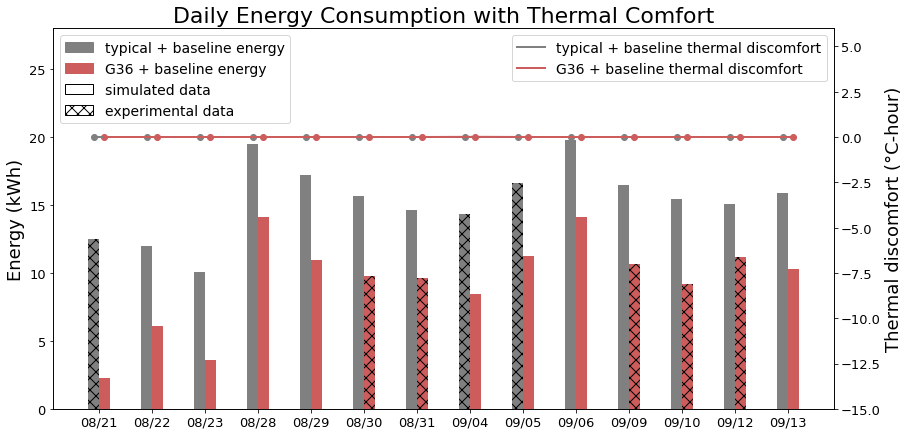

In [71]:
#MetricsCalculation_UseModel_G36NoDf=filter_dates_dataframe(model_data_G36NoDf[['temp_diff','cooling_electric_power']],CompareControlSequence_NoDf_days)




fig, (ax) = plt.subplots(nrows = 1, ncols = 1, constrained_layout=False, facecolor='w', edgecolor='k',figsize = (14,7))
fig.subplots_adjust(hspace = .2, wspace=.15)



# create labels for each date of the test
labels = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in full_dates]


x = np.arange(len(labels))
width = .2

ax.bar(np.array([1,2,3,4,5,6,9,10,11,12,13])-width*0.5, DailyTotalEnergy_UseModel_NonG36NoDf, width = width, color = 'grey')
ax.bar(np.array([0,7,8])-width*0.5, DailyTotalEnergy_UseTest1A_NonG36NoDf, width = width, color = 'grey',hatch= 'xx')


ax.bar(np.array([0,1,2,3,4,7,8,9,13])+width*0.5, DailyTotalEnergy_UseModel_G36NoDf, width = width, color = 'indianred')
ax.bar(np.array([5,6,10,11,12])+width*0.5, DailyTotalEnergy_UseTest1A_G36NoDf, width = width, color = 'indianred',hatch= 'xx')
#ax.bar(np.array([])+width*0.5, DailyTotalEnergy_UseTest1B_G36NoDf, width = width, color = 'indianred',hatch= 'xx')




#ax.bar(x+width*.5, en_g36, width = width, label='G36 Control', color = 'rosybrown')
#ax.bar(x+width*1.5, en_g36_dr, width = width, label='G36 Control + DR', color = 'indianred')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize = 12)
ax.set_title('Daily Energy Consumption with Thermal Comfort', fontsize = 22)
ax.set_ylabel('Energy (kWh)', fontsize = 18)
grey_patch = mpatches.Patch(color='grey', label='typical + baseline energy')
indianred_patch = mpatches.Patch(color='indianred', label='G36 + baseline energy')
simulated_patch = mpatches.Patch(label='simulated data',edgecolor='black',facecolor='white')
experimental_patch = mpatches.Patch(label='experimental data',edgecolor='black',facecolor='white',hatch= 'xx')
ax.legend(handles=[grey_patch, indianred_patch,simulated_patch,experimental_patch],fontsize = 14,loc=2)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)
ax.set_ylim(0,28)








ax2=ax.twinx()
ax2.scatter(x-width*0.5,DailyShoot_full_NonG36NoDf,  color='grey')
ax2.plot(x-width*0.5,DailyShoot_full_NonG36NoDf, label="typical + baseline thermal discomfort",color='grey',linewidth=2)

ax2.scatter(x+width*0.5,DailyShoot_full_G36NoDf,  color='indianred')
ax2.plot(x+width*0.5,DailyShoot_full_G36NoDf, label="G36 + baseline thermal discomfort",color='indianred',linewidth=2)


ax2.set_ylim(-15,6)


ax2.tick_params(axis="y", labelsize=13)
ax2.set_ylabel('Thermal discomfort (°C-hour)', fontsize = 18)
ax2.legend(fontsize = 14, loc = 1)


In [72]:
#FF6C6C #FF9745
#B5FFB5 #80FF80
#00FF00 #02B026
#DCDCFF #00F5FF
#7D7DFF #0051FF

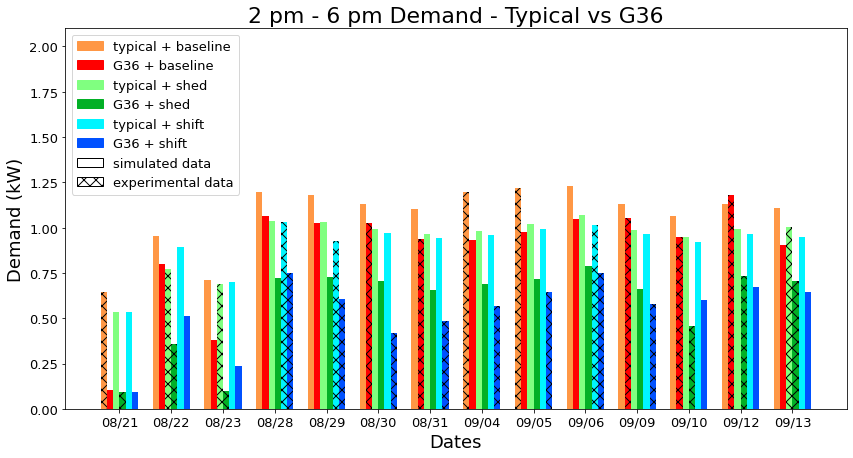

In [73]:
fig, (ax) = plt.subplots(nrows = 1, ncols = 1, constrained_layout=False, facecolor='w', edgecolor='k',figsize = (14,7))
fig.subplots_adjust(hspace = .2, wspace=.15)
#ax_right = ax.twinx()

#inp_day = dates_list#.tolist() #convert to a list

labels = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in full_dates]
#labels_UseModel = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in ['2021-08-20','2021-08-21','2021-09-10','2021-09-12']]
#labels_UseTest = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in ['2021-08-22','2021-08-23','2021-09-13']]
#labels1 = []
#for i in range(0,len(inp_day)):
#    labels.append(inp_day[i].strftime('%m/%d'))

#for i in range(0,len(inp_day)-1):
#    labels1.append(inp_day[i].strftime('%m/%d'))

x = np.arange(len(labels))
#print(labels)
#print(list_2)
width = .12


ax.bar(np.array([1,2,3,4,5,6,9,10,11,12,13])-width*2.5, AverageDemandShed_UseModel_NonG36NoDf, width = width, color = '#FF9745')
ax.bar(np.array([0,7,8])-width*2.5, AverageDemandShed_UseTest1A_NonG36NoDf, width = width, color = '#FF9745',hatch='xx')

ax.bar(np.array([0,1,2,3,4,7,8,9,13])-width*1.5, AverageDemandShed_UseModel_G36NoDf, width = width,  color = '#FF0000')
ax.bar(np.array([5,6,10,11,12])-width*1.5, AverageDemandShed_UseTest1A_G36NoDf, width = width,  color = '#FF0000',hatch='xx')

ax.bar(np.array([0,3,4,5,6,7,8,9,10,11,12])-width*.5, AverageDemandShed_UseModel_NonG36LoadShed, width = width, color = '#80FF80')
ax.bar(np.array([1,2,13])-width*.5, AverageDemandShed_UseTest1A_NonG36LoadShed, width = width, color = '#80FF80',hatch='xx')



ax.bar(np.array([3,4,5,6,7,8,9,10])+width*0.5, AverageDemandShed_UseModel_G36LoadShed, width = width,  color = '#02B026')
ax.bar(np.array([0,1,2,11,12,13])+width*0.5, AverageDemandShed_UseTest1B_G36LoadShed, width = width,  color = '#02B026',hatch='xx')

ax.bar(np.array([0,1,2,5,6,7,8,10,11,12,13])+width*1.5, AverageDemandShed_UseModel_NonG36LoadShift, width = width,  color = '#00F5FF')
ax.bar(np.array([3,4,9])+width*1.5, AverageDemandShed_UseTest1A_NonG36LoadShift, width = width,  color = '#00F5FF',hatch='xx')


ax.bar(np.array([0,1,2,11,12,13])+width*2.5, AverageDemandShed_UseModel_G36LoadShift, width = width,  color = '#0051FF')
ax.bar(np.array([3,4,5,6,7,8,9,10])+width*2.5, AverageDemandShed_UseTest1B_G36LoadShift, width = width,  color = '#0051FF',hatch='xx')
#ax_right.plot(x, DailyTotalEnergy_NonG36LoadShed, color='darkseagreen', marker='o', linestyle='dashed', linewidth=2, markersize=12, label ='typical Control - Daily total energy')
#ax_right.plot(x, DailyTotalEnergy_G36LoadShed, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12, label = 'G36 Control - Daily total energy')


ax.set_ylim(0,2.1)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels[0:len(labels)], fontsize = 12)
ax.set_title('2 pm - 6 pm Demand - Typical vs G36', fontsize = 22)
ax.set_ylabel('Demand (kW)', fontsize = 18)
ax.set_xlabel('Dates', fontsize = 18)
#ax.legend(fontsize = 14, loc = 2)

light_red_patch = mpatches.Patch(color='#FF9745', label='typical + baseline')
dark_red_patch = mpatches.Patch(color='#FF0000', label='G36 + baseline')
light_green_patch = mpatches.Patch(color='#80FF80', label='typical + shed')
dark_green_patch = mpatches.Patch(color='#02B026', label='G36 + shed')
light_blue_patch = mpatches.Patch(color='#00F5FF', label='typical + shift')
dark_blue_patch = mpatches.Patch(color='#0051FF', label='G36 + shift')

simulated_patch = mpatches.Patch(label='simulated data',edgecolor='black',facecolor='white')
experimental_patch = mpatches.Patch(label='experimental data',edgecolor='black',facecolor='white',hatch='xx')
ax.legend(handles=[light_red_patch, dark_red_patch,light_green_patch,dark_green_patch,light_blue_patch,dark_blue_patch,simulated_patch,experimental_patch],fontsize = 13, loc=2)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)
#ax_right.set_ylim(0,30)
#ax_right.set_ylabel('Daily total energy (kWh)', fontsize = 18)
#ax_right.legend(fontsize = 14, loc = 1)
#ax.set_yticklabels(range(0,1), fontsize = 12)
#FF9745 #FF0000 #80FF80 #02B026 #00F5FF #0051FF

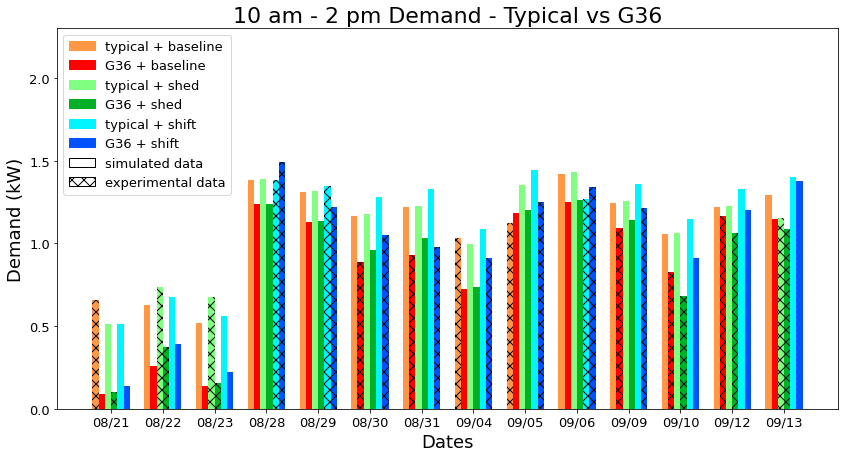

In [74]:
fig, (ax) = plt.subplots(nrows = 1, ncols = 1, constrained_layout=False, facecolor='w', edgecolor='k',figsize = (14,7))
fig.subplots_adjust(hspace = .2, wspace=.15)
#ax_right = ax.twinx()

#inp_day = dates_list#.tolist() #convert to a list

labels = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in full_dates]
#labels_UseModel = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in ['2021-08-20','2021-08-21','2021-09-10','2021-09-12']]
#labels_UseTest = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in ['2021-08-22','2021-08-23','2021-09-13']]
#labels1 = []
#for i in range(0,len(inp_day)):
#    labels.append(inp_day[i].strftime('%m/%d'))

#for i in range(0,len(inp_day)-1):
#    labels1.append(inp_day[i].strftime('%m/%d'))

x = np.arange(len(labels))
#print(labels)
#print(list_2)
width = .12


ax.bar(np.array([1,2,3,4,5,6,9,10,11,12,13])-width*2.5, AverageDemandPrecool_UseModel_NonG36NoDf, width = width, color = '#FF9745')
ax.bar(np.array([0,7,8])-width*2.5, AverageDemandPrecool_UseTest1A_NonG36NoDf, width = width, color = '#FF9745',hatch='xx')

ax.bar(np.array([0,1,2,3,4,7,8,9,13])-width*1.5, AverageDemandPrecool_UseModel_G36NoDf, width = width,  color = '#FF0000')
ax.bar(np.array([5,6,10,11,12])-width*1.5, AverageDemandPrecool_UseTest1A_G36NoDf, width = width,  color = '#FF0000',hatch='xx')

ax.bar(np.array([0,3,4,5,6,7,8,9,10,11,12])-width*.5, AverageDemandPrecool_UseModel_NonG36LoadShed, width = width, color = '#80FF80')
ax.bar(np.array([1,2,13])-width*.5, AverageDemandPrecool_UseTest1A_NonG36LoadShed, width = width, color = '#80FF80',hatch='xx')



ax.bar(np.array([3,4,5,6,7,8,9,10])+width*0.5, AverageDemandPrecool_UseModel_G36LoadShed, width = width,  color = '#02B026')
ax.bar(np.array([0,1,2,11,12,13])+width*0.5, AverageDemandPrecool_UseTest1B_G36LoadShed, width = width,  color = '#02B026',hatch='xx')

ax.bar(np.array([0,1,2,5,6,7,8,10,11,12,13])+width*1.5, AverageDemandPrecool_UseModel_NonG36LoadShift, width = width,  color = '#00F5FF')
ax.bar(np.array([3,4,9])+width*1.5, AverageDemandPrecool_UseTest1A_NonG36LoadShift, width = width,  color = '#00F5FF',hatch='xx')


ax.bar(np.array([0,1,2,11,12,13])+width*2.5, AverageDemandPrecool_UseModel_G36LoadShift, width = width,  color = '#0051FF')
ax.bar(np.array([3,4,5,6,7,8,9,10])+width*2.5, AverageDemandPrecool_UseTest1B_G36LoadShift, width = width,  color = '#0051FF',hatch='xx')
#ax_right.plot(x, DailyTotalEnergy_NonG36LoadShed, color='darkseagreen', marker='o', linestyle='dashed', linewidth=2, markersize=12, label ='typical Control - Daily total energy')
#ax_right.plot(x, DailyTotalEnergy_G36LoadShed, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12, label = 'G36 Control - Daily total energy')


ax.set_ylim(0,2.3)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels[0:len(labels)], fontsize = 12)
ax.set_title('10 am - 2 pm Demand - Typical vs G36', fontsize = 22)
ax.set_ylabel('Demand (kW)', fontsize = 18)
ax.set_xlabel('Dates', fontsize = 18)
#ax.legend(fontsize = 14, loc = 2)

light_red_patch = mpatches.Patch(color='#FF9745', label='typical + baseline')
dark_red_patch = mpatches.Patch(color='#FF0000', label='G36 + baseline')
light_green_patch = mpatches.Patch(color='#80FF80', label='typical + shed')
dark_green_patch = mpatches.Patch(color='#02B026', label='G36 + shed')
light_blue_patch = mpatches.Patch(color='#00F5FF', label='typical + shift')
dark_blue_patch = mpatches.Patch(color='#0051FF', label='G36 + shift')

simulated_patch = mpatches.Patch(label='simulated data',edgecolor='black',facecolor='white')
experimental_patch = mpatches.Patch(label='experimental data',edgecolor='black',facecolor='white',hatch= 'xx')
ax.legend(handles=[light_red_patch, dark_red_patch,light_green_patch,dark_green_patch,light_blue_patch,dark_blue_patch,simulated_patch,experimental_patch],fontsize = 13, loc=2)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)
#ax_right.set_ylim(0,30)
#ax_right.set_ylabel('Daily total energy (kWh)', fontsize = 18)
#ax_right.legend(fontsize = 14, loc = 1)
#ax.set_yticklabels(range(0,1), fontsize = 12)
#FF9745 #FF0000 #80FF80 #02B026 #00F5FF #0051FF



In [75]:
#3/0

In [76]:
"""
fig, (ax) = plt.subplots(nrows = 1, ncols = 1, constrained_layout=False, facecolor='w', edgecolor='k',figsize = (14,7))
fig.subplots_adjust(hspace = .2, wspace=.15)
#ax_right = ax.twinx()

#inp_day = dates_list#.tolist() #convert to a list

labels = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in full_dates]
#labels_UseModel = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in ['2021-08-20','2021-08-21','2021-09-10','2021-09-12']]
#labels_UseTest = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in ['2021-08-22','2021-08-23','2021-09-13']]
#labels1 = []
#for i in range(0,len(inp_day)):
#    labels.append(inp_day[i].strftime('%m/%d'))

#for i in range(0,len(inp_day)-1):
#    labels1.append(inp_day[i].strftime('%m/%d'))

x = np.arange(len(labels))
#print(labels)
#print(list_2)
width = .1


ax.bar(np.array([1,2,5,6,7])-width*2.5, DailyShoot_UseModel_NonG36NoDf, width = width, color = '#FFDCDC')
ax.bar(np.array([0,3,4])-width*2.5, DailyShoot_UseTest1A_NonG36NoDf, width = width, color = '#FFDCDC',hatch='xx')

ax.bar(np.array([0,3,4])-width*1.5, DailyShoot_UseModel_G36NoDf, width = width,  color = '#FF0000')
ax.bar(np.array([1,2,5,6,7])-width*1.5, DailyShoot_UseTest1A_G36NoDf, width = width,  color = '#FF0000',hatch='xx')

ax.bar(x-width*.5, DailyShoot_UseModel_NonG36LoadShed, width = width, color = '#DCFFDC')

ax.bar(np.array([1,2,3,4,5])+width*0.5, DailyShoot_UseModel_G36LoadShed, width = width,  color = '#00FF00')
ax.bar(np.array([0,6,7])+width*0.5, DailyShoot_UseTest1B_G36LoadShed, width = width,  color = '#00FF00',hatch='xx')

ax.bar(x+width*1.5, DailyShoot_UseModel_NonG36LoadShift, width = width,  color = '#DCDCFF')

ax.bar(np.array([0,6,7])+width*2.5, DailyShoot_UseModel_G36LoadShift, width = width,  color = '#0000FF')
ax.bar(np.array([1,2,3,4,5])+width*2.5, DailyShoot_UseTest1B_G36LoadShift, width = width,  color = '#0000FF',hatch='xx')
#ax_right.plot(x, DailyTotalEnergy_NonG36LoadShed, color='darkseagreen', marker='o', linestyle='dashed', linewidth=2, markersize=12, label ='non-G36 Control - Daily total energy')
#ax_right.plot(x, DailyTotalEnergy_G36LoadShed, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12, label = 'G36 Control - Daily total energy')


ax.set_ylim(0,11)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels[0:len(labels)], fontsize = 12)
ax.set_title('Daily South Zone Occupant Discomfort - Non-G36 vs G36', fontsize = 22)
ax.set_ylabel('Occupant discomfort (°C-hour)', fontsize = 18)
ax.set_xlabel('Dates', fontsize = 18)
#ax.legend(fontsize = 14, loc = 2)

light_red_patch = mpatches.Patch(color='#FFDCDC', label='non-G36 + no-DF')
dark_red_patch = mpatches.Patch(color='#FF0000', label='G36 + no-DF')
light_green_patch = mpatches.Patch(color='#DCFFDC', label='non-G36 + load-shed')
dark_green_patch = mpatches.Patch(color='#00FF00', label='G36 + load-shed')
light_blue_patch = mpatches.Patch(color='#DCDCFF', label='non-G36 + load-shift')
dark_blue_patch = mpatches.Patch(color='#0000FF', label='G36 + load-shift')

simulated_patch = mpatches.Patch(label='simulated data',edgecolor='black',facecolor='white')
experimental_patch = mpatches.Patch(label='experimental data',edgecolor='black',facecolor='white',hatch= 'xx')
ax.legend(handles=[light_red_patch, dark_red_patch,light_green_patch,dark_green_patch,light_blue_patch,dark_blue_patch,simulated_patch,experimental_patch],fontsize = 13, loc=2)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)
#ax_right.set_ylim(0,30)
#ax_right.set_ylabel('Daily total energy (kWh)', fontsize = 18)
#ax_right.legend(fontsize = 14, loc = 1)
#ax.set_yticklabels(range(0,1), fontsize = 12)
"""

'\nfig, (ax) = plt.subplots(nrows = 1, ncols = 1, constrained_layout=False, facecolor=\'w\', edgecolor=\'k\',figsize = (14,7))\nfig.subplots_adjust(hspace = .2, wspace=.15)\n#ax_right = ax.twinx()\n\n#inp_day = dates_list#.tolist() #convert to a list\n\nlabels = [pd.to_datetime(date_to_select).date().strftime(\'%m/%d\') for date_to_select in full_dates]\n#labels_UseModel = [pd.to_datetime(date_to_select).date().strftime(\'%m/%d\') for date_to_select in [\'2021-08-20\',\'2021-08-21\',\'2021-09-10\',\'2021-09-12\']]\n#labels_UseTest = [pd.to_datetime(date_to_select).date().strftime(\'%m/%d\') for date_to_select in [\'2021-08-22\',\'2021-08-23\',\'2021-09-13\']]\n#labels1 = []\n#for i in range(0,len(inp_day)):\n#    labels.append(inp_day[i].strftime(\'%m/%d\'))\n\n#for i in range(0,len(inp_day)-1):\n#    labels1.append(inp_day[i].strftime(\'%m/%d\'))\n\nx = np.arange(len(labels))\n#print(labels)\n#print(list_2)\nwidth = .1\n\n\nax.bar(np.array([1,2,5,6,7])-width*2.5, DailyShoot_UseModel_N

In [77]:
cooling_setpoint_no_df_index=[i/60 for i in range(0,1440,1)]
cooling_setpoint_no_df_value=[26.7]*60*5+[25.6]*60*1+[25]*60*1+[23.3]*60*15+[26.7]*60*2
cooling_setpoint_no_df=pd.Series(data=cooling_setpoint_no_df_value, index=cooling_setpoint_no_df_index)
cooling_setpoint_no_df

0.000000     26.7
0.016667     26.7
0.033333     26.7
0.050000     26.7
0.066667     26.7
             ... 
23.916667    26.7
23.933333    26.7
23.950000    26.7
23.966667    26.7
23.983333    26.7
Length: 1440, dtype: float64

In [78]:
cooling_setpoint_load_shed_index=[i/60 for i in range(0,1440,1)]
cooling_setpoint_load_shed_value=[26.7]*60*5+[25.6]*60*1+[25]*60*1+[23.3]*60*7+[25.6]*60*4+[23.3]*60*4+[26.7]*60*2
cooling_setpoint_load_shed=pd.Series(data=cooling_setpoint_load_shed_value, index=cooling_setpoint_load_shed_index)
cooling_setpoint_load_shed

0.000000     26.7
0.016667     26.7
0.033333     26.7
0.050000     26.7
0.066667     26.7
             ... 
23.916667    26.7
23.933333    26.7
23.950000    26.7
23.966667    26.7
23.983333    26.7
Length: 1440, dtype: float64

In [79]:
cooling_setpoint_load_shift_index=[i/60 for i in range(0,1440,1)]
cooling_setpoint_load_shift_value=[26.7]*60*5+[25.6]*60*1+[25]*60*1+[23.3]*60*3+[22.2]*60*4+[25.6]*60*4+[23.3]*60*4+[26.7]*60*2
cooling_setpoint_load_shift=pd.Series(data=cooling_setpoint_load_shift_value, index=cooling_setpoint_load_shift_index)
cooling_setpoint_load_shift

0.000000     26.7
0.016667     26.7
0.033333     26.7
0.050000     26.7
0.066667     26.7
             ... 
23.916667    26.7
23.933333    26.7
23.950000    26.7
23.966667    26.7
23.983333    26.7
Length: 1440, dtype: float64

In [80]:
heating_setpoint_all_cases_index=[i/60 for i in range(0,1440,1)]
heating_setpoint_all_cases_value=[15.6]*60*5+[17.8]*60*1+[19.4]*60*1+[21.1]*60*15+[15.6]*60*2
heating_setpoint_all_cases=pd.Series(data=heating_setpoint_all_cases_value, index=heating_setpoint_all_cases_index)
heating_setpoint_all_cases

0.000000     15.6
0.016667     15.6
0.033333     15.6
0.050000     15.6
0.066667     15.6
             ... 
23.916667    15.6
23.933333    15.6
23.950000    15.6
23.966667    15.6
23.983333    15.6
Length: 1440, dtype: float64

In [81]:
upper_comfort_limit_index=[i/60 for i in range(0,1440,1)]
upper_comfort_limit_value=[50]*60*7+[24]*60*15+[50]*60*2
upper_comfort_limit=pd.Series(data=upper_comfort_limit_value, index=upper_comfort_limit_index)
upper_comfort_limit

0.000000     50
0.016667     50
0.033333     50
0.050000     50
0.066667     50
             ..
23.916667    50
23.933333    50
23.950000    50
23.966667    50
23.983333    50
Length: 1440, dtype: int64

In [82]:
lower_comfort_limit_index=[i/60 for i in range(0,1440,1)]
lower_comfort_limit_value=[0]*60*7+[18]*60*15+[0]*60*2
lower_comfort_limit=pd.Series(data=lower_comfort_limit_value, index=lower_comfort_limit_index)
lower_comfort_limit

0.000000     0
0.016667     0
0.033333     0
0.050000     0
0.066667     0
            ..
23.916667    0
23.933333    0
23.950000    0
23.966667    0
23.983333    0
Length: 1440, dtype: int64

In [83]:
#model_data_NonG36NoDf
#model_data_NonG36LoadShed
#model_data_NonG36LoadShift
#model_data_G36NoDf
#model_data_G36LoadShed
#model_data_G36LoadShift

#test_data_cell1A
#test_data_cell1B

In [84]:
#filter_dates_hourly_index calculate_daily_average

In [85]:
"""
fig,ax=plt.subplots(nrows=2,ncols=1,figsize=(10,13))




ax[0].plot(cooling_setpoint_load_shift,label=r"Cooling/heating setpoint for load-shift",color="darkgray")
ax[0].plot(heating_setpoint_all_cases,color="darkgray")
ax[0].plot(upper_comfort_limit,label=r"Upper/lower thermal comfort limit",color="orange",linestyle='dashed')
ax[0].plot(lower_comfort_limit,color="orange",linestyle='dashed')


ax[0].plot(filter_dates_hourly_index(test_data_cell1A['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 non-G36 + no-DF, experimental", color="red",linestyle='dashed')
ax[0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 non-G36 + load-shed, simulated", color="green",linestyle='dashed')
ax[0].plot(filter_dates_hourly_index(model_data_NonG36LoadShift['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 non-G36 + load-shift, simulated", color="blue",linestyle='dashed')


ax[0].plot(filter_dates_hourly_index(model_data_G36NoDf['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 G36 + no-DF, simulated", color="red")
ax[0].plot(filter_dates_hourly_index(test_data_cell1B['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 G36 + load-shed, experimental", color="green")
ax[0].plot(filter_dates_hourly_index(model_data_G36LoadShift['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 G36 + load-shift, simulated", color="blue")




ax[0].legend(fontsize=11,loc=9,bbox_to_anchor=(0.6,0.42))
ax[0].set_title(f'South Zone Room Air Temperature,Setpoints, and Comfort Limits',fontsize=18)
#ax[0].set_xlabel('Hour of day',fontsize=17)
ax[0].set_ylabel('Temperature [°C]',fontsize=17)
ax[0].set_ylim(11,28.2)
ax[0].tick_params(axis="x", labelsize=13)
ax[0].tick_params(axis="y", labelsize=13)
#ax[0].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))

ax[1].plot(cooling_setpoint_load_shift,label=r"Cooling/heating setpoint for load-shift",color="darkgray")
ax[1].plot(heating_setpoint_all_cases,color="darkgray")
ax[1].plot(upper_comfort_limit,label=r"Upper/lower thermal comfort limit",color="orange",linestyle='dashed')
ax[1].plot(lower_comfort_limit,color="orange",linestyle='dashed')


ax[1].plot(filter_dates_hourly_index(test_data_cell1A['VAV: South Zone Room Air Temperature'],['2021-09-04']),label=r"2021-09-04 non-G36 + no-DF, experimental", color="red",linestyle='dashed')
ax[1].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['VAV: South Zone Room Air Temperature'],['2021-09-04']),label=r"2021-09-04 non-G36 + load-shed, simulated", color="green",linestyle='dashed')
ax[1].plot(filter_dates_hourly_index(model_data_NonG36LoadShift['VAV: South Zone Room Air Temperature'],['2021-09-04']),label=r"2021-09-04 non-G36 + load-shift, simulated", color="blue",linestyle='dashed')


ax[1].plot(filter_dates_hourly_index(model_data_G36NoDf['VAV: South Zone Room Air Temperature'],['2021-09-04']),label=r"2021-09-04 G36 + no-DF, simulated", color="red")
ax[1].plot(filter_dates_hourly_index(model_data_G36LoadShed['VAV: South Zone Room Air Temperature'],['2021-09-04']),label=r"2021-09-04 G36 + load-shed, simulated", color="green")
ax[1].plot(filter_dates_hourly_index(test_data_cell1B['VAV: South Zone Room Air Temperature'],['2021-09-04']),label=r"2021-09-04 G36 + load-shift, experimental", color="blue")




ax[1].legend(fontsize=11,loc=9,bbox_to_anchor=(0.6,0.42))
#ax[1].set_title(f'South Zone Room Air Temperature Compared to Setpoints and Comfort Limits',fontsize=15)
ax[1].set_xlabel('Hour of day',fontsize=17)
ax[1].set_ylabel('Temperature [°C]',fontsize=17)
ax[1].set_ylim(11,28.2)
ax[1].tick_params(axis="x", labelsize=13)
ax[1].tick_params(axis="y", labelsize=13)
#ax[1].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))
"""

'\nfig,ax=plt.subplots(nrows=2,ncols=1,figsize=(10,13))\n\n\n\n\nax[0].plot(cooling_setpoint_load_shift,label=r"Cooling/heating setpoint for load-shift",color="darkgray")\nax[0].plot(heating_setpoint_all_cases,color="darkgray")\nax[0].plot(upper_comfort_limit,label=r"Upper/lower thermal comfort limit",color="orange",linestyle=\'dashed\')\nax[0].plot(lower_comfort_limit,color="orange",linestyle=\'dashed\')\n\n\nax[0].plot(filter_dates_hourly_index(test_data_cell1A[\'VAV: South Zone Room Air Temperature\'],[\'2021-08-21\']),label=r"2021-08-21 non-G36 + no-DF, experimental", color="red",linestyle=\'dashed\')\nax[0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed[\'VAV: South Zone Room Air Temperature\'],[\'2021-08-21\']),label=r"2021-08-21 non-G36 + load-shed, simulated", color="green",linestyle=\'dashed\')\nax[0].plot(filter_dates_hourly_index(model_data_NonG36LoadShift[\'VAV: South Zone Room Air Temperature\'],[\'2021-08-21\']),label=r"2021-08-21 non-G36 + load-shift, simulated

In [86]:
"""
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(10,13))




ax[0].plot(cooling_setpoint_no_df,label=r"Cooling/heating setpoint for no-DF",color="darkgray")
ax[0].plot(heating_setpoint_all_cases,color="darkgray")
ax[0].plot(upper_comfort_limit,label=r"Upper/lower thermal comfort limit",color="orange",linestyle='dashed')
ax[0].plot(lower_comfort_limit,color="orange",linestyle='dashed')


ax[0].plot(filter_dates_hourly_index(test_data_cell1A['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 non-G36 + no-DF, experimental", color="blue",linestyle='dashed')
ax[0].plot(filter_dates_hourly_index(model_data_NonG36NoDf['VAV: South Zone Room Air Temperature'],['2021-09-12']),label=r"2021-09-12 non-G36 + no-DF, simulated", color="blue")
ax[0].plot(filter_dates_hourly_index(model_data_G36NoDf['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 G36 + no-DF, simulated", color="green",linestyle='dashed')
ax[0].plot(filter_dates_hourly_index(test_data_cell1A['VAV: South Zone Room Air Temperature'],['2021-09-12']),label=r"2021-09-12 G36 + no-DF, experimental", color="green")







ax[0].legend(fontsize=11,loc=9,bbox_to_anchor=(0.6,0.5))
ax[0].set_title(f'South Zone Room Air Temperature,Setpoints, and Comfort Limits',fontsize=18)
#ax[0].set_xlabel('Hour of day',fontsize=17)
ax[0].set_ylabel('Temperature [°C]',fontsize=17)
ax[0].set_ylim(8.4,28.2)
ax[0].tick_params(axis="x", labelsize=13)
ax[0].tick_params(axis="y", labelsize=13)
#ax[0].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))

ax[1].plot(cooling_setpoint_load_shed,label=r"Cooling/heating setpoint for load-shed",color="darkgray")
ax[1].plot(heating_setpoint_all_cases,color="darkgray")
ax[1].plot(upper_comfort_limit,label=r"Upper/lower thermal comfort limit",color="orange",linestyle='dashed')
ax[1].plot(lower_comfort_limit,color="orange",linestyle='dashed')

ax[1].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 non-G36 + load-shed, simulated", color="blue",linestyle='dashed')
ax[1].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['VAV: South Zone Room Air Temperature'],['2021-09-12']),label=r"2021-09-12 non-G36 + load-shed, simulated", color="blue")
ax[1].plot(filter_dates_hourly_index(test_data_cell1B['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 G36 + load-shed, experimental", color="green",linestyle='dashed')
ax[1].plot(filter_dates_hourly_index(test_data_cell1B['VAV: South Zone Room Air Temperature'],['2021-09-12']),label=r"2021-09-12 G36 + load-shed, experimental", color="green")






ax[1].legend(fontsize=11,loc=9,bbox_to_anchor=(0.6,0.5))
#ax[1].set_title(f'South Zone Room Air Temperature Compared to Setpoints and Comfort Limits',fontsize=15)
#ax[1].set_xlabel('Hour of day',fontsize=17)
ax[1].set_ylabel('Temperature [°C]',fontsize=17)
ax[1].set_ylim(8.4,28.2)
ax[1].tick_params(axis="x", labelsize=13)
ax[1].tick_params(axis="y", labelsize=13)
#ax[1].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))

ax[2].plot(cooling_setpoint_load_shift,label=r"Cooling/heating setpoint for load-shift",color="darkgray")
ax[2].plot(heating_setpoint_all_cases,color="darkgray")
ax[2].plot(upper_comfort_limit,label=r"Upper/lower thermal comfort limit",color="orange",linestyle='dashed')
ax[2].plot(lower_comfort_limit,color="orange",linestyle='dashed')

ax[2].plot(filter_dates_hourly_index(model_data_NonG36LoadShift['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 non-G36 + load-shift, simulated", color="blue",linestyle='dashed')
ax[2].plot(filter_dates_hourly_index(model_data_NonG36LoadShift['VAV: South Zone Room Air Temperature'],['2021-09-12']),label=r"2021-09-12 non-G36 + load-shift, simulated", color="blue")
ax[2].plot(filter_dates_hourly_index(model_data_G36LoadShift['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 G36 + load-shift, simulated", color="green",linestyle='dashed')
ax[2].plot(filter_dates_hourly_index(model_data_G36LoadShift['VAV: South Zone Room Air Temperature'],['2021-09-12']),label=r"2021-09-12 G36 + load-shift, simulated", color="green")


ax[2].legend(fontsize=11,loc=9,bbox_to_anchor=(0.6,0.5))
#ax[2].set_title(f'South Zone Room Air Temperature Compared to Setpoints and Comfort Limits',fontsize=15)
ax[2].set_xlabel('Hour of day',fontsize=17)
ax[2].set_ylabel('Temperature [°C]',fontsize=17)
ax[2].set_ylim(8.4,28.2)
ax[2].tick_params(axis="x", labelsize=13)
ax[2].tick_params(axis="y", labelsize=13)
#ax[2].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))
"""

'\nfig,ax=plt.subplots(nrows=3,ncols=1,figsize=(10,13))\n\n\n\n\nax[0].plot(cooling_setpoint_no_df,label=r"Cooling/heating setpoint for no-DF",color="darkgray")\nax[0].plot(heating_setpoint_all_cases,color="darkgray")\nax[0].plot(upper_comfort_limit,label=r"Upper/lower thermal comfort limit",color="orange",linestyle=\'dashed\')\nax[0].plot(lower_comfort_limit,color="orange",linestyle=\'dashed\')\n\n\nax[0].plot(filter_dates_hourly_index(test_data_cell1A[\'VAV: South Zone Room Air Temperature\'],[\'2021-08-21\']),label=r"2021-08-21 non-G36 + no-DF, experimental", color="blue",linestyle=\'dashed\')\nax[0].plot(filter_dates_hourly_index(model_data_NonG36NoDf[\'VAV: South Zone Room Air Temperature\'],[\'2021-09-12\']),label=r"2021-09-12 non-G36 + no-DF, simulated", color="blue")\nax[0].plot(filter_dates_hourly_index(model_data_G36NoDf[\'VAV: South Zone Room Air Temperature\'],[\'2021-08-21\']),label=r"2021-08-21 G36 + no-DF, simulated", color="green",linestyle=\'dashed\')\nax[0].plot(filte

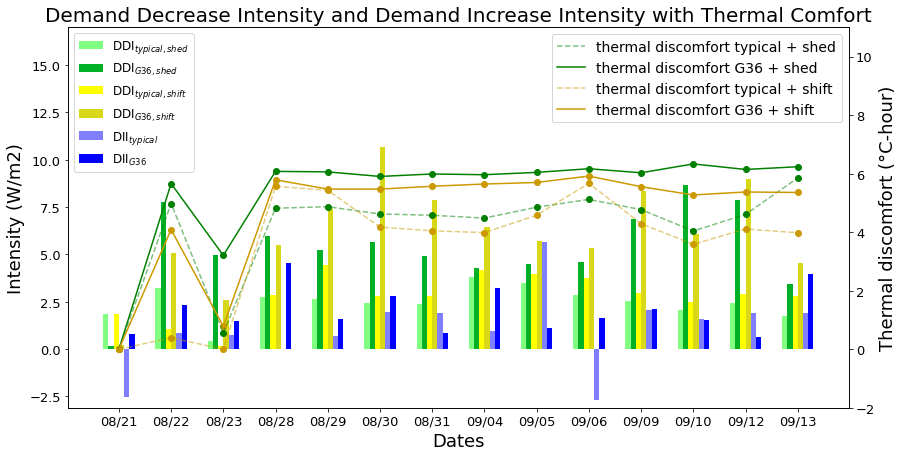

In [87]:
fig, (ax) = plt.subplots(nrows = 1, ncols = 1, constrained_layout=False, facecolor='w', edgecolor='k',figsize = (14,7))
fig.subplots_adjust(hspace = .2, wspace=.15)


labels = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in full_dates]



x = np.arange(len(labels))
#print(labels)
#print(list_2)
width = .1

ax.bar(x-width*2.5, ShedIntensity_full_NonG36LoadShed, width = width, color = '#80FF80',label='DDI$_{typical, shed}$')#DCFFDC


ax.bar(x-width*1.5, ShedIntensity_full_G36LoadShed, width = width,  color = '#02b026', label='DDI$_{G36, shed}$')#00FF00

ax.bar(x-width*.5, ShedIntensity_full_NonG36LoadShift, width = width, color = '#ffff00', label='DDI$_{typical, shift}$')#DCFFFF


ax.bar(x+width*0.5, ShedIntensity_full_G36LoadShift, width = width,  color = '#d8d819', label='DDI$_{G36, shift}$')#00FFFF

ax.bar(x+width*1.5, ShiftIntensity_full_NonG36LoadShift, width = width,  color = '#8080ff', label='DII$_{typical}$')

ax.bar(x+width*2.5, ShiftIntensity_full_G36LoadShift, width = width,  color = '#0000ff', label='DII$_{G36}$')



ax.set_ylim(-3.1,17)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels[0:len(labels)], fontsize = 12)
ax.set_title('Demand Decrease Intensity and Demand Increase Intensity with Thermal Comfort', fontsize = 20)
ax.set_ylabel('Intensity (W/m2)', fontsize = 18)
ax.set_xlabel('Dates', fontsize = 18)




ax.legend(fontsize = 12, loc=2)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)
#ax_right.set_ylim(0,30)
#ax_right.set_ylabel('Daily total energy (kWh)', fontsize = 18)
#ax_right.legend(fontsize = 14, loc = 1)
#ax.set_yticklabels(range(0,1), fontsize = 12)




ax2=ax.twinx()
ax2.scatter(x,DailyShoot_full_NonG36LoadShed,  color='green')
ax2.plot(x,DailyShoot_full_NonG36LoadShed, label="thermal discomfort typical + shed",color='green',linestyle='dashed',alpha=0.5)

ax2.scatter(x,DailyShoot_full_G36LoadShed,  color='green')
ax2.plot(x,DailyShoot_full_G36LoadShed, label="thermal discomfort G36 + shed",color='green')


ax2.scatter(x,DailyShoot_full_NonG36LoadShift,  color='#CC9900')
ax2.plot(x,DailyShoot_full_NonG36LoadShift, label="thermal discomfort typical + shift",color='#CC9900',linestyle='dashed',alpha=0.5)

ax2.scatter(x,DailyShoot_full_G36LoadShift,  color='#CC9900')
ax2.plot(x,DailyShoot_full_G36LoadShift, label="thermal discomfort G36 + shift",color='#CC9900')



ax2.set_ylim(-2,11)


ax2.tick_params(axis="y", labelsize=13)
ax2.set_ylabel('Thermal discomfort (°C-hour)', fontsize = 18)
ax2.legend(fontsize = 14, loc = 1)


In [88]:
# average outdoor air temperature
average_outdoor_air_temperature=model_data_NonG36NoDf['Outdoor Air Temperature'].resample('D').mean()
average_outdoor_air_temperature

# maximum outdoor air temperature
maximum_outdoor_air_temperature=model_data_NonG36NoDf['Outdoor Air Temperature'].resample('D').max()
maximum_outdoor_air_temperature

datetime
2021-08-14    21.106598
2021-08-15    22.200073
2021-08-16    26.685852
2021-08-17    21.839996
2021-08-18    20.201904
2021-08-19    20.700684
2021-08-20    17.672882
2021-08-21    15.804993
2021-08-22    19.957855
2021-08-23    18.000854
2021-08-24    19.172577
2021-08-25    20.109009
2021-08-26    24.441833
2021-08-27    30.436096
2021-08-28    30.333923
2021-08-29    25.463196
2021-08-30    22.202880
2021-08-31    20.018890
2021-09-01    19.137054
2021-09-02    19.600555
2021-09-03    19.304993
2021-09-04    24.107178
2021-09-05    26.603851
2021-09-06    29.347198
2021-09-07    23.400818
2021-09-08    26.401794
2021-09-09    21.644958
2021-09-10    19.500427
2021-09-11    20.713226
2021-09-12    24.585968
2021-09-13    22.930756
2021-09-14    21.333344
2021-09-15    15.000000
Freq: D, Name: Outdoor Air Temperature, dtype: float64

In [89]:
average_outdoor_air_temperature_list=average_outdoor_air_temperature.loc[full_dates].to_list()
maximum_outdoor_air_temperature_list=maximum_outdoor_air_temperature.loc[full_dates].to_list()


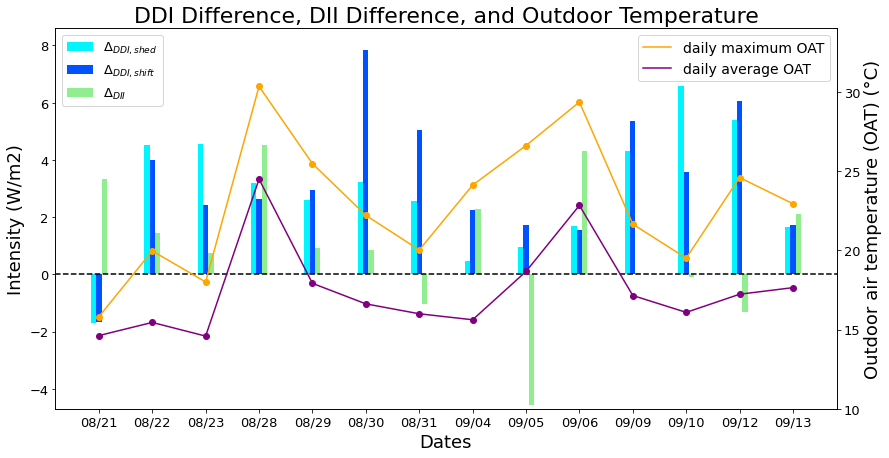

In [90]:
fig, (ax) = plt.subplots(nrows = 1, ncols = 1, constrained_layout=False, facecolor='w', edgecolor='k',figsize = (14,7))
fig.subplots_adjust(hspace = .2, wspace=.15)


labels = [pd.to_datetime(date_to_select).date().strftime('%m/%d') for date_to_select in full_dates]


average_outdoor_air_temperature_list=average_outdoor_air_temperature.loc[full_dates].to_list()
maximum_outdoor_air_temperature_list=maximum_outdoor_air_temperature.loc[full_dates].to_list()

x = np.arange(len(labels))
#print(labels)
#print(list_2)
width = .1

ax.bar(x-width*1, AdditionalShedIntensityForLoadShed, width = width, color = '#00f5ff',label='Δ$_{DDI, shed}$')


ax.bar(x+width*0, AdditionalShedIntensityForLoadShift, width = width,  color = '#0051ff', label='Δ$_{DDI, shift}$')
ax.bar(x+width*1, AdditionalShiftIntensityForLoadShift, width = width,  color = 'lightgreen', label='Δ$_{DII}$')


#ax.bar(x+width*1, ShiftIntensity_NonG36LoadShift, width = width,  color = '#DCDCFF', label='shift intensity in non-G36')

#ax.bar(x+width*2, ShiftIntensity_G36LoadShift, width = width,  color = '#0000FF', label='shift intensity in G36')
ax.axhline(y=0, color='k', linestyle='--')


ax.set_ylim(-4.7,8.6)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels[0:len(labels)], fontsize = 12)
ax.set_title('DDI Difference, DII Difference, and Outdoor Temperature', fontsize = 22)
ax.set_ylabel('Intensity (W/m2)', fontsize = 18)
ax.set_xlabel('Dates', fontsize = 18)
#ax.legend(fontsize = 14, loc = 2)



ax.legend(fontsize = 13, loc=2)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)
#ax_right.set_ylim(0,30)
#ax_right.set_ylabel('Daily total energy (kWh)', fontsize = 18)
#ax_right.legend(fontsize = 14, loc = 1)
#ax.set_yticklabels(range(0,1), fontsize = 12)




ax2=ax.twinx()
ax2.scatter(x,maximum_outdoor_air_temperature_list,  color='orange')
ax2.plot(x,maximum_outdoor_air_temperature_list, label="daily maximum OAT",color='orange')

ax2.scatter(x,average_outdoor_air_temperature_list,  color='purple')
ax2.plot(x,average_outdoor_air_temperature_list, label="daily average OAT",color='purple')


ax2.set_ylim(10,34)


ax2.tick_params(axis="y", labelsize=13)
ax2.set_ylabel('Outdoor air temperature (OAT) (°C)', fontsize = 18)
ax2.legend(fontsize = 14, loc = 1)


(0.0, 1.0, 0.0, 1.0)

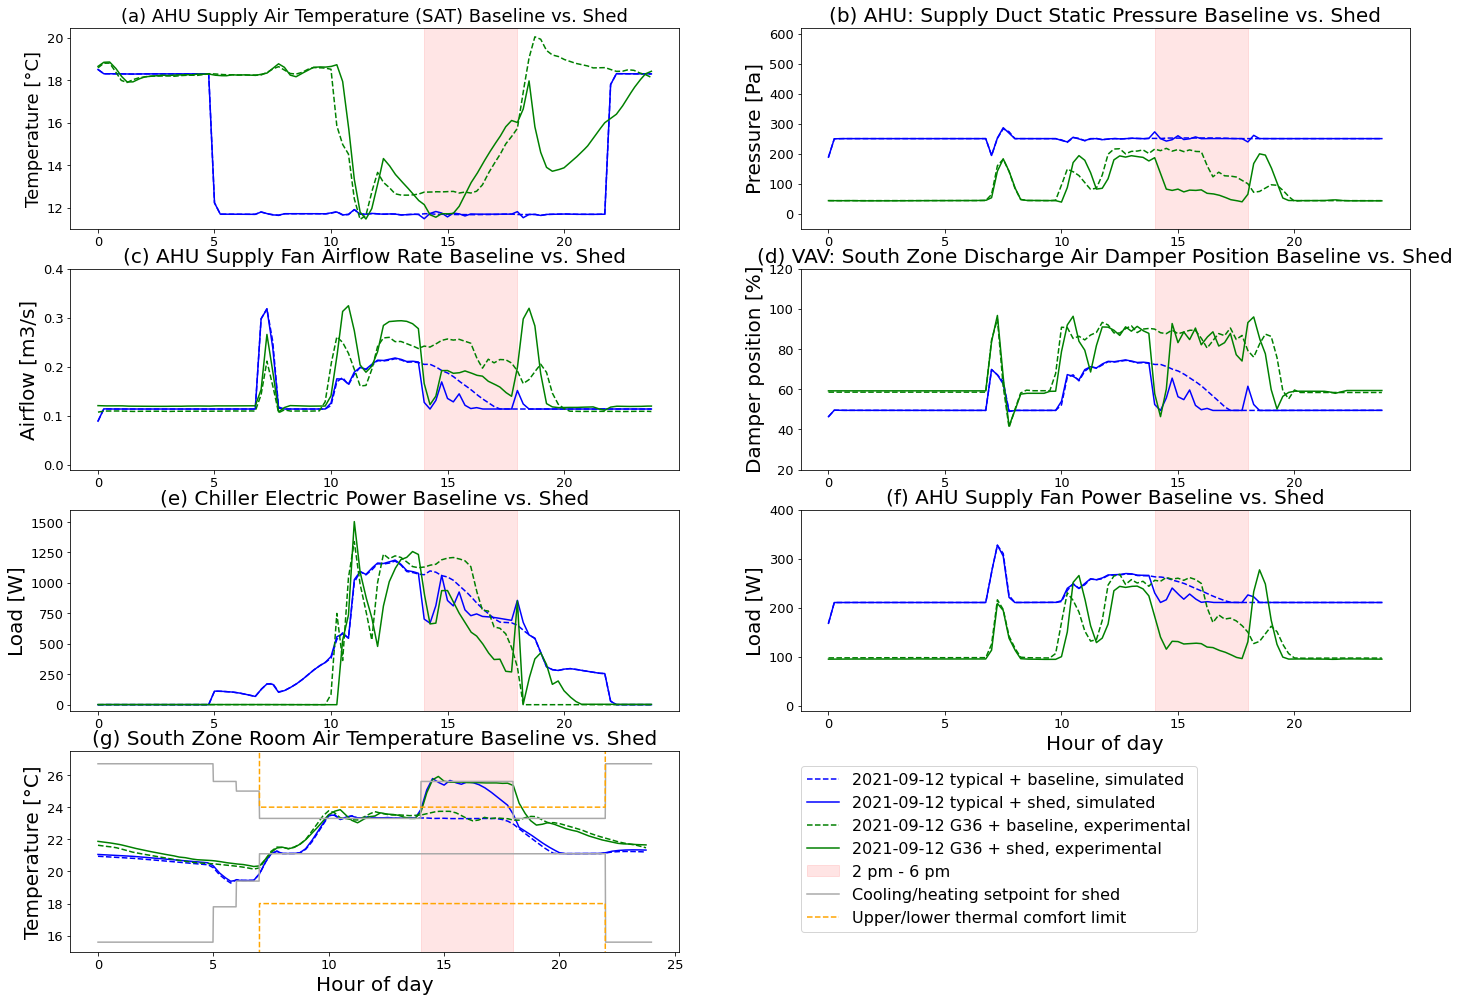

In [91]:
fig,ax=plt.subplots(nrows=4,ncols=2,figsize=(24,17))



ax[0,0].plot(filter_dates_hourly_index(model_data_NonG36NoDf['AHU: Supply Air Temperature'],['2021-09-12']),label=r"2021-09-12 typical + baseline, simulated",linestyle='dashed',color="blue")#,linewidth=4)
ax[0,0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['AHU: Supply Air Temperature'],['2021-09-12']),label=r"2021-09-12 typical + shed, simulated",color="blue")



ax[0,0].plot(filter_dates_hourly_index(test_data_cell1A['AHU: Supply Air Temperature'],['2021-09-12']),label=r"2021-09-12 G36 + baseline, experimental",linestyle='dashed', color="green")#,linewidth=4)
ax[0,0].plot(filter_dates_hourly_index(test_data_cell1B['AHU: Supply Air Temperature'],['2021-09-12']),label=r"2021-09-12 G36 + shed, experimental", color="green")




ax[0,0].axvspan(14, \
              18, \
              color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[0,0].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")
#ax[0,0].legend(fontsize=12,loc=2)
ax[0,0].set_title(f'(a) AHU Supply Air Temperature (SAT) Baseline vs. Shed',fontsize=18)
#ax[0,0].set_xlabel('Hour of day',fontsize=18)
ax[0,0].set_ylabel('Temperature [°C]',fontsize=18)

#ax[0,0].set_ylim(11,26)
ax[0,0].tick_params(axis="x", labelsize=13)
ax[0,0].tick_params(axis="y", labelsize=13)



ax[1,0].plot(filter_dates_hourly_index(model_data_NonG36NoDf['AHU: Supply Fan Airflow Rate'],['2021-09-12']),label=r"2021-09-12 typical + baseline, simulated",linestyle='dashed',color="blue")
ax[1,0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['AHU: Supply Fan Airflow Rate'],['2021-09-12']),label=r"2021-09-12 typical + shed, simulated",color="blue")

ax[1,0].plot(filter_dates_hourly_index(test_data_cell1A['AHU: Supply Fan Airflow Rate'],['2021-09-12']),label=r"2021-09-12 G36 + baseline, experimental",linestyle='dashed', color="green")
ax[1,0].plot(filter_dates_hourly_index(test_data_cell1B['AHU: Supply Fan Airflow Rate'],['2021-09-12']),label=r"2021-09-12 G36 + shed, experimental", color="green")


ax[1,0].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[1,0].axvspan(10, 14, color='#0000FF', alpha=0.1,label="Precool period")



#ax[1,0].legend(fontsize=13)
ax[1,0].set_title(f'(c) AHU Supply Fan Airflow Rate Baseline vs. Shed',fontsize=20)
#ax[1,0].set_xlabel('Hour of day',fontsize=20)
ax[1,0].set_ylabel('Airflow [m3/s]',fontsize=20)
ax[1,0].tick_params(axis="x", labelsize=13)
ax[1,0].tick_params(axis="y", labelsize=13)
ax[1,0].set_ylim(-0.01,0.4)
#ax[1,0].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))



ax[2,0].plot(filter_dates_hourly_index(model_data_NonG36NoDf['chiller_load'],['2021-09-12']),label=r"2021-09-12 typical + baseline, simulated",linestyle='dashed',color="blue")
ax[2,0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['chiller_load'],['2021-09-12']),label=r"2021-09-12 typical + shed, simulated",color="blue")

ax[2,0].plot(filter_dates_hourly_index(test_data_cell1A['chiller_load'],['2021-09-12']),label=r"2021-09-12 G36 + baseline, experimental",linestyle='dashed', color="green")
ax[2,0].plot(filter_dates_hourly_index(test_data_cell1B['chiller_load'],['2021-09-12']),label=r"2021-09-12 G36 + shed, experimental", color="green")




ax[2,0].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[2,0].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")

#ax[2,0].legend(fontsize=13,loc=2)
ax[2,0].set_title(f'(e) Chiller Electric Power Baseline vs. Shed',fontsize=20)
#ax[2,0].set_xlabel('Hour of day',fontsize=20)
ax[2,0].set_ylabel('Load [W]',fontsize=20)
#ax[2,0].set_xticklabels(x_ticks, rotation=0, fontsize=13)
#ax[2,0].set_yticklabels(y_ticks, rotation=0, fontsize=13)
ax[2,0].tick_params(axis="x", labelsize=13)
ax[2,0].tick_params(axis="y", labelsize=13)

ax[2,0].set_ylim(-50,1600)

ax[3,0].plot(filter_dates_hourly_index(model_data_NonG36NoDf['VAV: South Zone Room Air Temperature'],['2021-09-12']),label=r"2021-09-12 typical + baseline, simulated",linestyle='dashed',color="blue")
ax[3,0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['VAV: South Zone Room Air Temperature'],['2021-09-12']),label=r"2021-09-12 typical + shed, simulated",color="blue")

ax[3,0].plot(filter_dates_hourly_index(test_data_cell1A['VAV: South Zone Room Air Temperature'],['2021-09-12']),label=r"2021-09-12 G36 + baseline, experimental",linestyle='dashed', color="green")
ax[3,0].plot(filter_dates_hourly_index(test_data_cell1B['VAV: South Zone Room Air Temperature'],['2021-09-12']),label=r"2021-09-12 G36 + shed, experimental", color="green")




ax[3,0].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[3,0].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")


#ax[0,0].legend(fontsize=12,loc=2)
ax[3,0].set_title(f'(g) South Zone Room Air Temperature Baseline vs. Shed',fontsize=20)
ax[3,0].set_xlabel('Hour of day',fontsize=20)
ax[3,0].set_ylabel('Temperature [°C]',fontsize=20)
#ax[3,0].set_xticklabels(x_ticks, rotation=0, fontsize=13)
#ax[3,0].set_yticklabels(y_ticks, rotation=0, fontsize=13)
ax[3,0].tick_params(axis="x", labelsize=13)
ax[3,0].tick_params(axis="y", labelsize=13)

ax[3,0].set_ylim(15,27.5)
ax[3,0].plot(cooling_setpoint_load_shed,label=r"Cooling/heating setpoint for shed",color="darkgray")
ax[3,0].plot(heating_setpoint_all_cases,color="darkgray")
ax[3,0].plot(upper_comfort_limit,label=r"Upper/lower thermal comfort limit",color="orange",linestyle='dashed')
ax[3,0].plot(lower_comfort_limit,color="orange",linestyle='dashed')
ax[3,0].legend(fontsize=16,loc=(1.2,0.1))




ax[0,1].plot(filter_dates_hourly_index(model_data_NonG36NoDf['AHU: Supply Duct Static Pressure'],['2021-09-12']),label=r"2021-09-12 typical + baseline, simulated",linestyle='dashed',color="blue")
ax[0,1].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['AHU: Supply Duct Static Pressure'],['2021-09-12']),label=r"2021-09-12 typical + shed, simulated",color="blue")

ax[0,1].plot(filter_dates_hourly_index(test_data_cell1A['AHU: Supply Duct Static Pressure'],['2021-09-12']),label=r"2021-09-12 G36 + baseline, experimental",linestyle='dashed', color="green")
ax[0,1].plot(filter_dates_hourly_index(test_data_cell1B['AHU: Supply Duct Static Pressure'],['2021-09-12']),label=r"2021-09-12 G36 + shed, experimental", color="green")




ax[0,1].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[0,1].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")

#ax[0,1].legend(fontsize=13,loc=2)
ax[0,1].set_title(f'(b) AHU: Supply Duct Static Pressure Baseline vs. Shed',fontsize=20)
#ax[0,1].set_xlabel('Hour of day',fontsize=20)
ax[0,1].set_ylabel('Pressure [Pa]',fontsize=20)
ax[0,1].tick_params(axis="x", labelsize=13)
ax[0,1].tick_params(axis="y", labelsize=13)
#ax[0,1].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))
ax[0,1].set_ylim(-50,620)

ax[1,1].plot(filter_dates_hourly_index(model_data_NonG36NoDf['VAV: South Zone Discharge Air Damper Position'],['2021-09-12']),label=r"2021-09-12 typical + baseline, simulated",linestyle='dashed',color="blue")
ax[1,1].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['VAV: South Zone Discharge Air Damper Position'],['2021-09-12']),label=r"2021-09-12 typical + shed, simulated",color="blue")

ax[1,1].plot(filter_dates_hourly_index(test_data_cell1A['VAV: South Zone Discharge Air Damper Position'],['2021-09-12']),label=r"2021-09-12 G36 + baseline, experimental",linestyle='dashed', color="green")
ax[1,1].plot(filter_dates_hourly_index(test_data_cell1B['VAV: South Zone Discharge Air Damper Position'],['2021-09-12']),label=r"2021-09-12 G36 + shed, experimental", color="green")




ax[1,1].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[1,1].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")

#ax[1,1].legend(fontsize=13)
ax[1,1].set_title(f'(d) VAV: South Zone Discharge Air Damper Position Baseline vs. Shed',fontsize=20)
#ax[1,1].set_xlabel('Hour of day',fontsize=20)
ax[1,1].set_ylabel('Damper position [%]',fontsize=20)
ax[1,1].tick_params(axis="x", labelsize=13)
ax[1,1].tick_params(axis="y", labelsize=13)
#ax[1,1].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))
ax[1,1].set_ylim(20,120)



ax[2,1].plot(filter_dates_hourly_index(model_data_NonG36NoDf['AHU: Supply Fan Power'],['2021-09-12']),label=r"2021-09-12 typical + baseline, simulated",linestyle='dashed',color="blue")
ax[2,1].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['AHU: Supply Fan Power'],['2021-09-12']),label=r"2021-09-12 typical + shed, simulated",color="blue")

ax[2,1].plot(filter_dates_hourly_index(test_data_cell1A['AHU: Supply Fan Power'],['2021-09-12']),label=r"2021-09-12 G36 + baseline, experimental",linestyle='dashed', color="green")
ax[2,1].plot(filter_dates_hourly_index(test_data_cell1B['AHU: Supply Fan Power'],['2021-09-12']),label=r"2021-09-12 G36 + shed, experimental", color="green")


ax[2,1].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[2,1].axvspan(10, 14, color='#0000FF', alpha=0.1,label="Precool period")



#ax[2,1].legend(fontsize=13)
ax[2,1].set_title(f'(f) AHU Supply Fan Power Baseline vs. Shed',fontsize=20)
ax[2,1].set_xlabel('Hour of day',fontsize=20)
ax[2,1].set_ylabel('Load [W]',fontsize=20)
ax[2,1].tick_params(axis="x", labelsize=13)
ax[2,1].tick_params(axis="y", labelsize=13)
ax[2,1].set_ylim(-10,400)
#ax[2,1].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))

ax[3,1].axis('off')

In [92]:
#VAV: South Zone Room Air Temperature chiller_load

(0.0, 1.0, 0.0, 1.0)

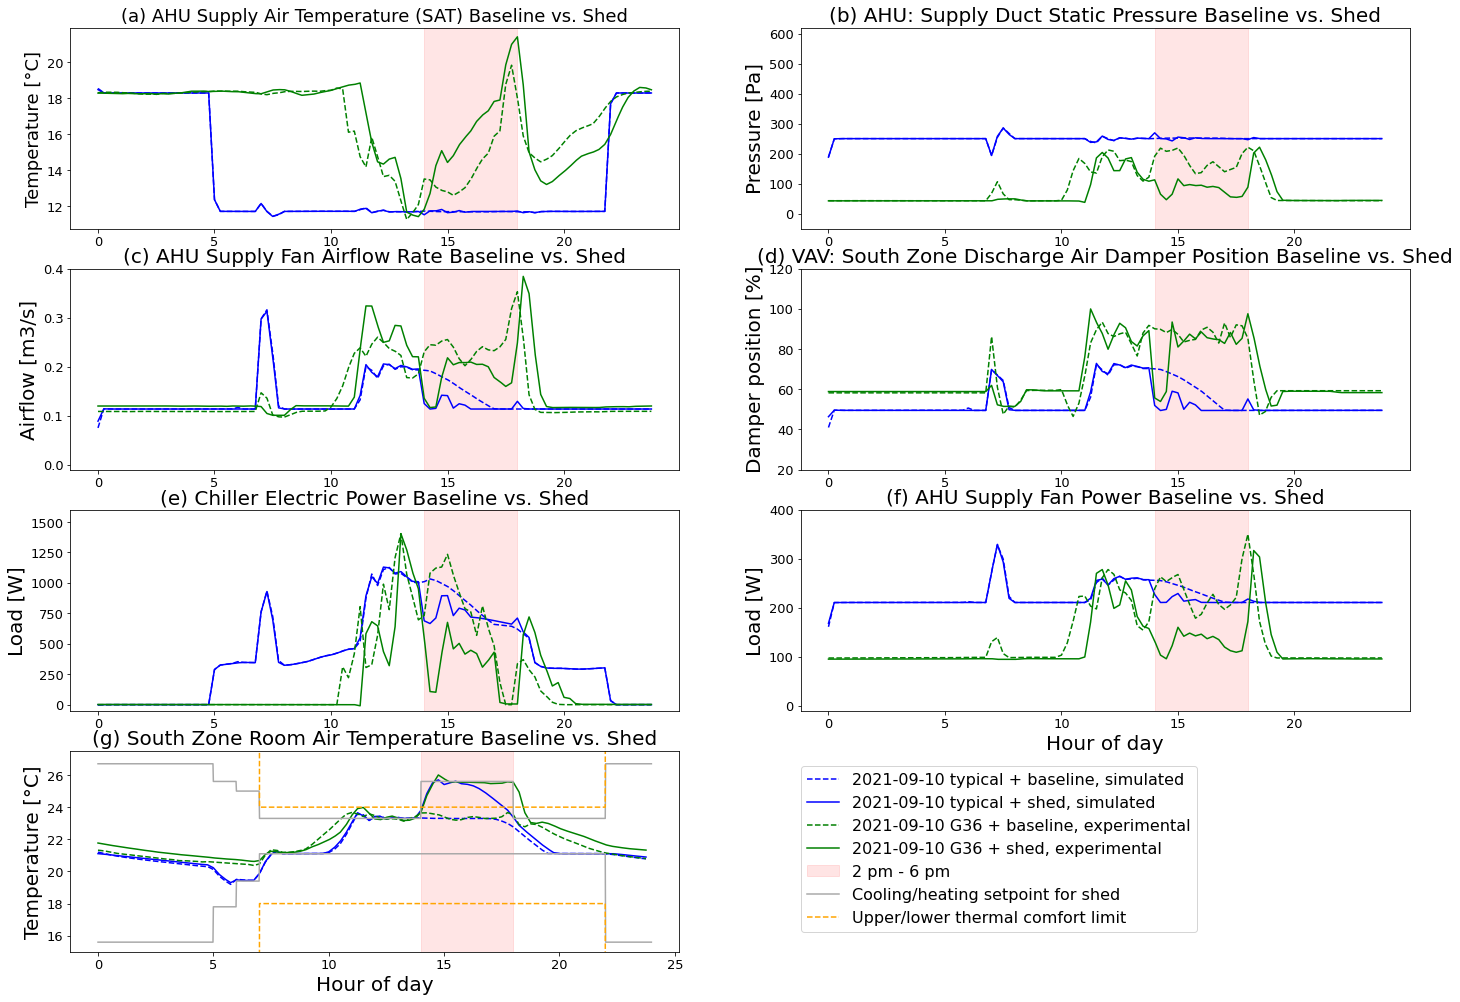

In [93]:
fig,ax=plt.subplots(nrows=4,ncols=2,figsize=(24,17))



ax[0,0].plot(filter_dates_hourly_index(model_data_NonG36NoDf['AHU: Supply Air Temperature'],['2021-09-10']),label=r"2021-09-10 typical + baseline, simulated",linestyle='dashed',color="blue")#,linewidth=4)
ax[0,0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['AHU: Supply Air Temperature'],['2021-09-10']),label=r"2021-09-10 typical + shed, simulated",color="blue")



ax[0,0].plot(filter_dates_hourly_index(test_data_cell1A['AHU: Supply Air Temperature'],['2021-09-10']),label=r"2021-09-10 G36 + baseline, experimental",linestyle='dashed', color="green")#,linewidth=4)
ax[0,0].plot(filter_dates_hourly_index(test_data_cell1B['AHU: Supply Air Temperature'],['2021-09-10']),label=r"2021-09-10 G36 + shed, experimental", color="green")




ax[0,0].axvspan(14, \
              18, \
              color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[0,0].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")
#ax[0,0].legend(fontsize=12,loc=2)
ax[0,0].set_title(f'(a) AHU Supply Air Temperature (SAT) Baseline vs. Shed',fontsize=18)
#ax[0,0].set_xlabel('Hour of day',fontsize=18)
ax[0,0].set_ylabel('Temperature [°C]',fontsize=18)

#ax[0,0].set_ylim(11,26)
ax[0,0].tick_params(axis="x", labelsize=13)
ax[0,0].tick_params(axis="y", labelsize=13)



ax[1,0].plot(filter_dates_hourly_index(model_data_NonG36NoDf['AHU: Supply Fan Airflow Rate'],['2021-09-10']),label=r"2021-09-10 typical + baseline, simulated",linestyle='dashed',color="blue")
ax[1,0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['AHU: Supply Fan Airflow Rate'],['2021-09-10']),label=r"2021-09-10 typical + shed, simulated",color="blue")

ax[1,0].plot(filter_dates_hourly_index(test_data_cell1A['AHU: Supply Fan Airflow Rate'],['2021-09-10']),label=r"2021-09-10 G36 + baseline, experimental",linestyle='dashed', color="green")
ax[1,0].plot(filter_dates_hourly_index(test_data_cell1B['AHU: Supply Fan Airflow Rate'],['2021-09-10']),label=r"2021-09-10 G36 + shed, experimental", color="green")


ax[1,0].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[1,0].axvspan(10, 14, color='#0000FF', alpha=0.1,label="Precool period")



#ax[1,0].legend(fontsize=13)
ax[1,0].set_title(f'(c) AHU Supply Fan Airflow Rate Baseline vs. Shed',fontsize=20)
#ax[1,0].set_xlabel('Hour of day',fontsize=20)
ax[1,0].set_ylabel('Airflow [m3/s]',fontsize=20)
ax[1,0].tick_params(axis="x", labelsize=13)
ax[1,0].tick_params(axis="y", labelsize=13)
ax[1,0].set_ylim(-0.01,0.4)
#ax[1,0].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))



ax[2,0].plot(filter_dates_hourly_index(model_data_NonG36NoDf['chiller_load'],['2021-09-10']),label=r"2021-09-10 typical + baseline, simulated",linestyle='dashed',color="blue")
ax[2,0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['chiller_load'],['2021-09-10']),label=r"2021-09-10 typical + shed, simulated",color="blue")

ax[2,0].plot(filter_dates_hourly_index(test_data_cell1A['chiller_load'],['2021-09-10']),label=r"2021-09-10 G36 + baseline, experimental",linestyle='dashed', color="green")
ax[2,0].plot(filter_dates_hourly_index(test_data_cell1B['chiller_load'],['2021-09-10']),label=r"2021-09-10 G36 + shed, experimental", color="green")




ax[2,0].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[2,0].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")

#ax[2,0].legend(fontsize=13,loc=2)
ax[2,0].set_title(f'(e) Chiller Electric Power Baseline vs. Shed',fontsize=20)
#ax[2,0].set_xlabel('Hour of day',fontsize=20)
ax[2,0].set_ylabel('Load [W]',fontsize=20)
#ax[2,0].set_xticklabels(x_ticks, rotation=0, fontsize=13)
#ax[2,0].set_yticklabels(y_ticks, rotation=0, fontsize=13)
ax[2,0].tick_params(axis="x", labelsize=13)
ax[2,0].tick_params(axis="y", labelsize=13)

ax[2,0].set_ylim(-50,1600)


ax[3,0].plot(filter_dates_hourly_index(model_data_NonG36NoDf['VAV: South Zone Room Air Temperature'],['2021-09-10']),label=r"2021-09-10 typical + baseline, simulated",linestyle='dashed',color="blue")
ax[3,0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['VAV: South Zone Room Air Temperature'],['2021-09-10']),label=r"2021-09-10 typical + shed, simulated",color="blue")

ax[3,0].plot(filter_dates_hourly_index(test_data_cell1A['VAV: South Zone Room Air Temperature'],['2021-09-10']),label=r"2021-09-10 G36 + baseline, experimental",linestyle='dashed', color="green")
ax[3,0].plot(filter_dates_hourly_index(test_data_cell1B['VAV: South Zone Room Air Temperature'],['2021-09-10']),label=r"2021-09-10 G36 + shed, experimental", color="green")




ax[3,0].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[3,0].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")




ax[3,0].set_title(f'(g) South Zone Room Air Temperature Baseline vs. Shed',fontsize=20)
ax[3,0].set_xlabel('Hour of day',fontsize=20)
ax[3,0].set_ylabel('Temperature [°C]',fontsize=20)
#ax[3,0].set_xticklabels(x_ticks, rotation=0, fontsize=13)
#ax[3,0].set_yticklabels(y_ticks, rotation=0, fontsize=13)
ax[3,0].tick_params(axis="x", labelsize=13)
ax[3,0].tick_params(axis="y", labelsize=13)

ax[3,0].set_ylim(15,27.5)
ax[3,0].plot(cooling_setpoint_load_shed,label=r"Cooling/heating setpoint for shed",color="darkgray")
ax[3,0].plot(heating_setpoint_all_cases,color="darkgray")
ax[3,0].plot(upper_comfort_limit,label=r"Upper/lower thermal comfort limit",color="orange",linestyle='dashed')
ax[3,0].plot(lower_comfort_limit,color="orange",linestyle='dashed')
ax[3,0].legend(fontsize=16,loc=(1.2,0.1))



ax[0,1].plot(filter_dates_hourly_index(model_data_NonG36NoDf['AHU: Supply Duct Static Pressure'],['2021-09-10']),label=r"2021-09-10 typical + baseline, simulated",linestyle='dashed',color="blue")
ax[0,1].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['AHU: Supply Duct Static Pressure'],['2021-09-10']),label=r"2021-09-10 typical + shed, simulated",color="blue")

ax[0,1].plot(filter_dates_hourly_index(test_data_cell1A['AHU: Supply Duct Static Pressure'],['2021-09-10']),label=r"2021-09-10 G36 + baseline, experimental",linestyle='dashed', color="green")
ax[0,1].plot(filter_dates_hourly_index(test_data_cell1B['AHU: Supply Duct Static Pressure'],['2021-09-10']),label=r"2021-09-10 G36 + shed, experimental", color="green")




ax[0,1].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[0,1].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")

#ax[0,1].legend(fontsize=13,loc=2)
ax[0,1].set_title(f'(b) AHU: Supply Duct Static Pressure Baseline vs. Shed',fontsize=20)
#ax[0,1].set_xlabel('Hour of day',fontsize=20)
ax[0,1].set_ylabel('Pressure [Pa]',fontsize=20)
ax[0,1].tick_params(axis="x", labelsize=13)
ax[0,1].tick_params(axis="y", labelsize=13)
#ax[0,1].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))
ax[0,1].set_ylim(-50,620)

ax[1,1].plot(filter_dates_hourly_index(model_data_NonG36NoDf['VAV: South Zone Discharge Air Damper Position'],['2021-09-10']),label=r"2021-09-10 typical + baseline, simulated",linestyle='dashed',color="blue")
ax[1,1].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['VAV: South Zone Discharge Air Damper Position'],['2021-09-10']),label=r"2021-09-10 typical + shed, simulated",color="blue")

ax[1,1].plot(filter_dates_hourly_index(test_data_cell1A['VAV: South Zone Discharge Air Damper Position'],['2021-09-10']),label=r"2021-09-10 G36 + baseline, experimental",linestyle='dashed', color="green")
ax[1,1].plot(filter_dates_hourly_index(test_data_cell1B['VAV: South Zone Discharge Air Damper Position'],['2021-09-10']),label=r"2021-09-10 G36 + shed, experimental", color="green")




ax[1,1].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[1,1].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")

#ax[1,1].legend(fontsize=13)
ax[1,1].set_title(f'(d) VAV: South Zone Discharge Air Damper Position Baseline vs. Shed',fontsize=20)
#ax[1,1].set_xlabel('Hour of day',fontsize=20)
ax[1,1].set_ylabel('Damper position [%]',fontsize=20)
ax[1,1].tick_params(axis="x", labelsize=13)
ax[1,1].tick_params(axis="y", labelsize=13)
#ax[1,1].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))
ax[1,1].set_ylim(20,120)



ax[2,1].plot(filter_dates_hourly_index(model_data_NonG36NoDf['AHU: Supply Fan Power'],['2021-09-10']),label=r"2021-09-10 typical + baseline, simulated",linestyle='dashed',color="blue")
ax[2,1].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['AHU: Supply Fan Power'],['2021-09-10']),label=r"2021-09-10 typical + shed, simulated",color="blue")

ax[2,1].plot(filter_dates_hourly_index(test_data_cell1A['AHU: Supply Fan Power'],['2021-09-10']),label=r"2021-09-10 G36 + baseline, experimental",linestyle='dashed', color="green")
ax[2,1].plot(filter_dates_hourly_index(test_data_cell1B['AHU: Supply Fan Power'],['2021-09-10']),label=r"2021-09-10 G36 + shed, experimental", color="green")

#ax[2,1].plot(filter_dates_hourly_index(model_data_G36NoDf['AHU: Supply Fan Power'],['2021-09-10']),label=r"2021-09-10 G36 + baseline, experimental",linestyle='dashed', color="red")

ax[2,1].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[2,1].axvspan(10, 14, color='#0000FF', alpha=0.1,label="Precool period")



#ax[2,1].legend(fontsize=13)
ax[2,1].set_title(f'(f) AHU Supply Fan Power Baseline vs. Shed',fontsize=20)
ax[2,1].set_xlabel('Hour of day',fontsize=20)
ax[2,1].set_ylabel('Load [W]',fontsize=20)
ax[2,1].tick_params(axis="x", labelsize=13)
ax[2,1].tick_params(axis="y", labelsize=13)
ax[2,1].set_ylim(-10,400)
#ax[2,1].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))
#fig.savefig('MediumPowerCombinedProfiles.png', dpi=fig.dpi)

ax[3,1].axis('off')

(0.0, 1.0, 0.0, 1.0)

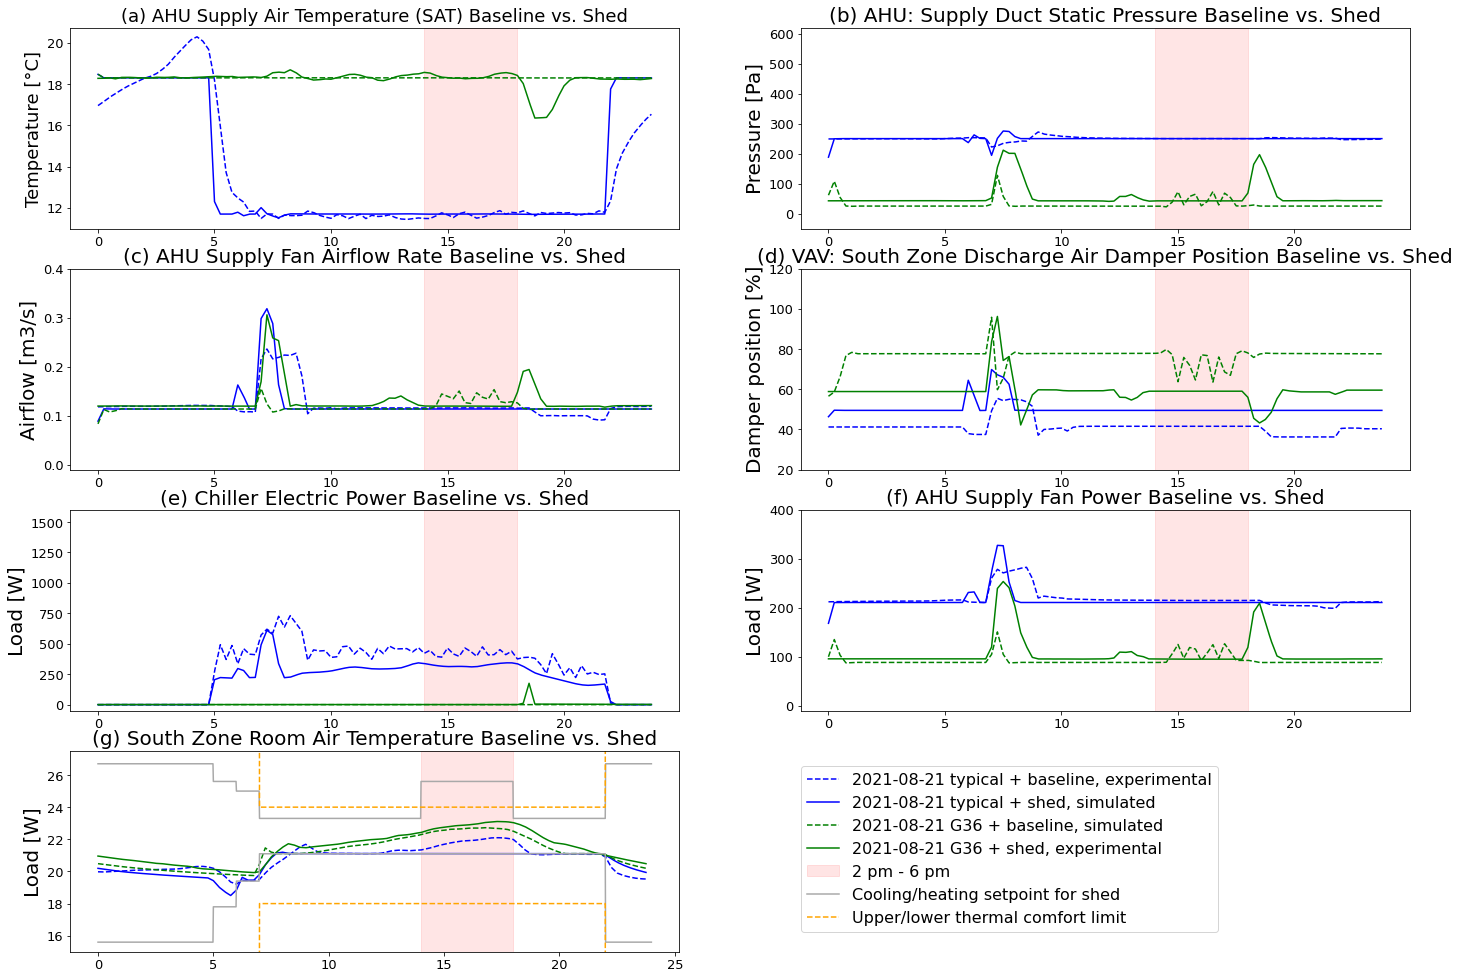

In [94]:
fig,ax=plt.subplots(nrows=4,ncols=2,figsize=(24,17))



ax[0,0].plot(filter_dates_hourly_index(test_data_cell1A['AHU: Supply Air Temperature'],['2021-08-21']),label=r"2021-08-21 typical + baseline, experimental",linestyle='dashed',color="blue")#,linewidth=4)
ax[0,0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['AHU: Supply Air Temperature'],['2021-08-21']),label=r"2021-08-21 typical + shed, simulated",color="blue")



ax[0,0].plot(filter_dates_hourly_index(model_data_G36NoDf['AHU: Supply Air Temperature'],['2021-08-21']),label=r"2021-08-21 G36 + baseline, simulated",linestyle='dashed', color="green")#,linewidth=4)
ax[0,0].plot(filter_dates_hourly_index(test_data_cell1B['AHU: Supply Air Temperature'],['2021-08-21']),label=r"2021-08-21 G36 + shed, experimental", color="green")




ax[0,0].axvspan(14, \
              18, \
              color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[0,0].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")
#ax[0,0].legend(fontsize=12,loc=2)
ax[0,0].set_title(f'(a) AHU Supply Air Temperature (SAT) Baseline vs. Shed',fontsize=18)
#ax[0,0].set_xlabel('Hour of day',fontsize=18)
ax[0,0].set_ylabel('Temperature [°C]',fontsize=18)

#ax[0,0].set_ylim(11,26)
ax[0,0].tick_params(axis="x", labelsize=13)
ax[0,0].tick_params(axis="y", labelsize=13)



ax[1,0].plot(filter_dates_hourly_index(test_data_cell1A['AHU: Supply Fan Airflow Rate'],['2021-08-21']),label=r"2021-08-21 typical + baseline, experimental",linestyle='dashed',color="blue")
ax[1,0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['AHU: Supply Fan Airflow Rate'],['2021-08-21']),label=r"2021-08-21 typical + shed, simulated",color="blue")

ax[1,0].plot(filter_dates_hourly_index(model_data_G36NoDf['AHU: Supply Fan Airflow Rate'],['2021-08-21']),label=r"2021-08-21 G36 + baseline, simulated",linestyle='dashed', color="green")
ax[1,0].plot(filter_dates_hourly_index(test_data_cell1B['AHU: Supply Fan Airflow Rate'],['2021-08-21']),label=r"2021-08-21 G36 + shed, experimental", color="green")


ax[1,0].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[1,0].axvspan(10, 14, color='#0000FF', alpha=0.1,label="Precool period")



#ax[1,0].legend(fontsize=13)
ax[1,0].set_title(f'(c) AHU Supply Fan Airflow Rate Baseline vs. Shed',fontsize=20)
#ax[1,0].set_xlabel('Hour of day',fontsize=20)
ax[1,0].set_ylabel('Airflow [m3/s]',fontsize=20)
ax[1,0].tick_params(axis="x", labelsize=13)
ax[1,0].tick_params(axis="y", labelsize=13)
ax[1,0].set_ylim(-0.01,0.4)
#ax[1,0].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))



ax[2,0].plot(filter_dates_hourly_index(test_data_cell1A['chiller_load'],['2021-08-21']),label=r"2021-08-21 typical + baseline, experimental",linestyle='dashed',color="blue")
ax[2,0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['chiller_load'],['2021-08-21']),label=r"2021-08-21 typical + shed, simulated",color="blue")

ax[2,0].plot(filter_dates_hourly_index(model_data_G36NoDf['chiller_load'],['2021-08-21']),label=r"2021-08-21 G36 + baseline, simulated",linestyle='dashed', color="green")
ax[2,0].plot(filter_dates_hourly_index(test_data_cell1B['chiller_load'],['2021-08-21']),label=r"2021-08-21 G36 + shed, experimental", color="green")




ax[2,0].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[2,0].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")

#ax[2,0].legend(fontsize=13,loc=2)
ax[2,0].set_title(f'(e) Chiller Electric Power Baseline vs. Shed',fontsize=20)
#ax[2,0].set_xlabel('Hour of day',fontsize=20)
ax[2,0].set_ylabel('Load [W]',fontsize=20)
#ax[2,0].set_xticklabels(x_ticks, rotation=0, fontsize=13)
#ax[2,0].set_yticklabels(y_ticks, rotation=0, fontsize=13)
ax[2,0].tick_params(axis="x", labelsize=13)
ax[2,0].tick_params(axis="y", labelsize=13)

ax[2,0].set_ylim(-50,1600)


ax[3,0].plot(filter_dates_hourly_index(test_data_cell1A['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 typical + baseline, experimental",linestyle='dashed',color="blue")
ax[3,0].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 typical + shed, simulated",color="blue")

ax[3,0].plot(filter_dates_hourly_index(model_data_G36NoDf['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 G36 + baseline, simulated",linestyle='dashed', color="green")
ax[3,0].plot(filter_dates_hourly_index(test_data_cell1B['VAV: South Zone Room Air Temperature'],['2021-08-21']),label=r"2021-08-21 G36 + shed, experimental", color="green")




ax[3,0].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[3,0].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")


ax[3,0].set_title(f'(g) South Zone Room Air Temperature Baseline vs. Shed',fontsize=20)
#ax[3,0].set_xlabel('Hour of day',fontsize=20)
ax[3,0].set_ylabel('Load [W]',fontsize=20)
#ax[3,0].set_xticklabels(x_ticks, rotation=0, fontsize=13)
#ax[3,0].set_yticklabels(y_ticks, rotation=0, fontsize=13)
ax[3,0].tick_params(axis="x", labelsize=13)
ax[3,0].tick_params(axis="y", labelsize=13)


ax[3,0].set_ylim(15,27.5)
ax[3,0].plot(cooling_setpoint_load_shed,label=r"Cooling/heating setpoint for shed",color="darkgray")
ax[3,0].plot(heating_setpoint_all_cases,color="darkgray")
ax[3,0].plot(upper_comfort_limit,label=r"Upper/lower thermal comfort limit",color="orange",linestyle='dashed')
ax[3,0].plot(lower_comfort_limit,color="orange",linestyle='dashed')
ax[3,0].legend(fontsize=16,loc=(1.2,0.1))

ax[3,0].legend(fontsize=16,loc=(1.2,0.1))


ax[0,1].plot(filter_dates_hourly_index(test_data_cell1A['AHU: Supply Duct Static Pressure'],['2021-08-21']),label=r"2021-08-21 typical + baseline, experimental",linestyle='dashed',color="blue")
ax[0,1].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['AHU: Supply Duct Static Pressure'],['2021-08-21']),label=r"2021-08-21 typical + shed, simulated",color="blue")

ax[0,1].plot(filter_dates_hourly_index(model_data_G36NoDf['AHU: Supply Duct Static Pressure'],['2021-08-21']),label=r"2021-08-21 G36 + baseline, simulated",linestyle='dashed', color="green")
ax[0,1].plot(filter_dates_hourly_index(test_data_cell1B['AHU: Supply Duct Static Pressure'],['2021-08-21']),label=r"2021-08-21 G36 + shed, experimental", color="green")




ax[0,1].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[0,1].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")

#ax[0,1].legend(fontsize=13,loc=2)
ax[0,1].set_title(f'(b) AHU: Supply Duct Static Pressure Baseline vs. Shed',fontsize=20)
#ax[0,1].set_xlabel('Hour of day',fontsize=20)
ax[0,1].set_ylabel('Pressure [Pa]',fontsize=20)
ax[0,1].tick_params(axis="x", labelsize=13)
ax[0,1].tick_params(axis="y", labelsize=13)
#ax[0,1].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))
ax[0,1].set_ylim(-50,620)

ax[1,1].plot(filter_dates_hourly_index(test_data_cell1A['VAV: South Zone Discharge Air Damper Position'],['2021-08-21']),label=r"2021-08-21 typical + baseline, experimental",linestyle='dashed',color="blue")
ax[1,1].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['VAV: South Zone Discharge Air Damper Position'],['2021-08-21']),label=r"2021-08-21 typical + shed, simulated",color="blue")

ax[1,1].plot(filter_dates_hourly_index(model_data_G36NoDf['VAV: South Zone Discharge Air Damper Position'],['2021-08-21']),label=r"2021-08-21 G36 + baseline, simulated",linestyle='dashed', color="green")
ax[1,1].plot(filter_dates_hourly_index(test_data_cell1B['VAV: South Zone Discharge Air Damper Position'],['2021-08-21']),label=r"2021-08-21 G36 + shed, experimental", color="green")




ax[1,1].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[1,1].axvspan(10, 14, color='#0000FF', alpha=0.1,label="\"shift\" period")

#ax[1,1].legend(fontsize=13)
ax[1,1].set_title(f'(d) VAV: South Zone Discharge Air Damper Position Baseline vs. Shed',fontsize=20)
#ax[1,1].set_xlabel('Hour of day',fontsize=20)
ax[1,1].set_ylabel('Damper position [%]',fontsize=20)
ax[1,1].tick_params(axis="x", labelsize=13)
ax[1,1].tick_params(axis="y", labelsize=13)
#ax[1,1].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))
ax[1,1].set_ylim(20,120)



ax[2,1].plot(filter_dates_hourly_index(test_data_cell1A['AHU: Supply Fan Power'],['2021-08-21']),label=r"2021-08-21 typical + baseline, experimental",linestyle='dashed',color="blue")
ax[2,1].plot(filter_dates_hourly_index(model_data_NonG36LoadShed['AHU: Supply Fan Power'],['2021-08-21']),label=r"2021-08-21 typical + shed, simulated",color="blue")

ax[2,1].plot(filter_dates_hourly_index(model_data_G36NoDf['AHU: Supply Fan Power'],['2021-08-21']),label=r"2021-08-21 G36 + baseline, simulated",linestyle='dashed', color="green")
ax[2,1].plot(filter_dates_hourly_index(test_data_cell1B['AHU: Supply Fan Power'],['2021-08-21']),label=r"2021-08-21 G36 + shed, experimental", color="green")


ax[2,1].axvspan(14, 18, color='#FF0000', alpha=0.1,label="2 pm - 6 pm")
#ax[2,1].axvspan(10, 14, color='#0000FF', alpha=0.1,label="Precool period")



#ax[2,1].legend(fontsize=13)
ax[2,1].set_title(f'(f) AHU Supply Fan Power Baseline vs. Shed',fontsize=20)
#ax[2,1].set_xlabel('Hour of day',fontsize=20)
ax[2,1].set_ylabel('Load [W]',fontsize=20)
ax[2,1].tick_params(axis="x", labelsize=13)
ax[2,1].tick_params(axis="y", labelsize=13)
ax[2,1].set_ylim(-10,400)
#ax[2,1].set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))

ax[3,1].axis('off')

In [95]:
#VAV: South Zone Room Air Temperature chiller_load

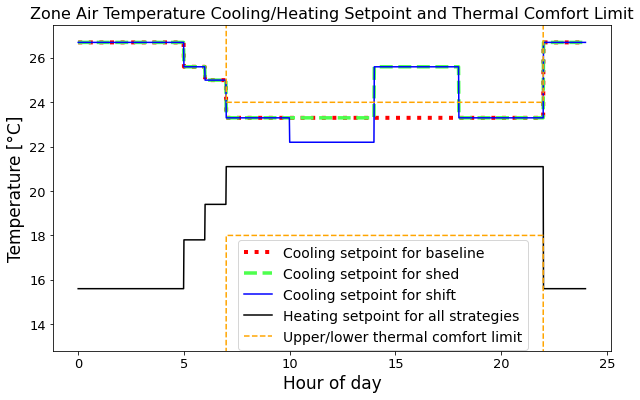

In [96]:
fig,ax=plt.subplots(nrows=1,ncols=1,figsize=(10,6))


ax.plot(cooling_setpoint_no_df,label=r"Cooling setpoint for baseline",color="red",linestyle='dotted', linewidth=4)


ax.plot(cooling_setpoint_load_shed,label=r"Cooling setpoint for shed",color="#4DFF4D",linestyle='dashed',linewidth=3.5)


ax.plot(cooling_setpoint_load_shift,label=r"Cooling setpoint for shift",color="blue")
ax.plot(heating_setpoint_all_cases,label=r"Heating setpoint for all strategies",color="black")

ax.plot(upper_comfort_limit,label=r"Upper/lower thermal comfort limit",color="orange",linestyle='dashed')
ax.plot(lower_comfort_limit,color="orange",linestyle='dashed')


ax.legend(fontsize=14,loc=0,bbox_to_anchor=(0.32,0.36))
ax.set_title(f'Zone Air Temperature Cooling/Heating Setpoint and Thermal Comfort Limit',fontsize=16)
ax.set_xlabel('Hour of day',fontsize=17)
ax.set_ylabel('Temperature [°C]',fontsize=17)
ax.set_ylim(12.8,27.5)
_=plt.yticks(fontsize=13)
_=plt.xticks(fontsize=13)
#ax.set_xlim(datetime.date(2021, 9,3),datetime.date(2021, 9,4))

In [97]:
3/0

ZeroDivisionError: division by zero